<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/%20%20%20%20notebooks/GVH_Stellar_Solar_Benchmark_0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark stellaire GVH 0.1
## Production radiale d’énergie solaire comme transition physique contrôlée

### Objectif

Ce notebook applique le cadre descriptif **GVH Dynamic** à la structure radiale du Soleil, en utilisant comme observable physique principale la production locale d’énergie en fonction du rayon solaire.

L’objectif est de tester si les observables géométriques multi-échelles GVH peuvent détecter, caractériser et quantifier une transition physique réelle entre :

- le **cœur solaire énergétiquement actif**, où se produit l’essentiel de la fusion nucléaire ;
- les régions externes, où la production nucléaire locale devient faible ou négligeable.

Le profil étudié est représenté sous la forme :

\[
r \longmapsto \epsilon(r),
\]

où :

- \(r\) désigne la coordonnée radiale dans le Soleil ;
- \(\epsilon(r)\) désigne la puissance locale produite par unité de volume, exprimée par exemple en \(\mathrm{W\,m^{-3}}\).

À partir de ce profil radial, le pipeline construit les observables GVH :

\[
D_T,\quad S_T,\quad S_T^{\rm norm},\quad D_c,\quad
R_{\rm super},\quad A_H,\quad B_H,
\]

ainsi que, lorsque leur définition géométrique est applicable :

\[
\theta_{\rm mean},\quad \theta_{\max},\quad R_{180}.
\]

### Question scientifique

La question centrale est :

> **Les observables GVH peuvent-elles détecter et caractériser une transition physique contrôlée entre une région solaire à forte production nucléaire et une région où cette production devient faible ou négligeable ?**

### Statut méthodologique

Cette version **0.1** constitue un benchmark descriptif et reproductible.

Elle ne suppose pas que les observables GVH possèdent déjà une interprétation physique fondamentale dans la structure stellaire.

L’objectif est d’abord de tester :

1. la sensibilité aux gradients radiaux ;
2. la détection de changements de régime ;
3. la stabilité des observables sous variation de résolution ;
4. la robustesse au bruit numérique ;
5. la reproductibilité des résultats.

Toute interprétation théorique éventuelle dans le cadre du **Volume Partagé** devra être étudiée séparément.

In [ ]:
# ============================================================
# 2. Imports et configuration de l'environnement
# ============================================================

import sys
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

warnings.filterwarnings("default")

# Configuration d'affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

np.set_printoptions(
    precision=6,
    suppress=True
)

# Reproductibilité
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Informations générales
print("Environnement initialisé avec succès.")
print(f"Python      : {sys.version.split()[0]}")
print(f"Plateforme  : {platform.platform()}")
print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")

Environnement initialisé avec succès.
Python      : 3.12.13
Plateforme  : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy       : 2.0.2
pandas      : 2.2.2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Données physiques du benchmark solaire

Le benchmark nécessite un profil radial de référence décrivant la production locale d’énergie dans le Soleil :

\[
r \longmapsto \epsilon(r).
\]

La variable radiale sera de préférence normalisée par le rayon solaire :

\[
x = \frac{r}{R_\odot},
\]

avec :

\[
0 \leq x \leq 1.
\]

La grandeur \(\epsilon(r)\) représente la production locale d’énergie nucléaire par unité de volume.

Afin de préserver le caractère contrôlé et reproductible du benchmark, les données utilisées devront provenir d’une source physique explicitement documentée.

Aucune valeur GVH ne sera figée avant le chargement, la validation et l’inspection du profil radial de référence.

## 4. Source physique et stratégie de construction du profil solaire

Le benchmark repose sur un profil radial solaire issu d'une source physique documentée.

La variable spatiale principale est le rayon solaire normalisé :

\[
x = \frac{r}{R_\odot},
\qquad 0 \leq x \leq 1.
\]

Les grandeurs physiques recherchées sont idéalement :

\[
T(x),\qquad \rho(x),\qquad P(x),
\]

ainsi que la production locale d'énergie nucléaire :

\[
\epsilon_{\rm nuc}(x).
\]

### Principe méthodologique

Le pipeline distingue explicitement :

1. les données physiques d'entrée ;
2. le prétraitement et l'interpolation ;
3. la construction du profil radial énergétique ;
4. le calcul des observables GVH ;
5. les tests de robustesse et de sensibilité.

Aucune valeur du profil solaire ne sera inventée ou reconstruite à partir d'une simple figure illustrative.

Le benchmark utilisera une source numérique documentée et reproductible.

## 5. Téléchargement du modèle solaire standard BS2005-OP

Le profil physique utilisé dans ce benchmark est issu du modèle solaire standard
**BS2005-OP**, associé aux travaux de John N. Bahcall et collaborateurs.

Le fichier contient les variables suivantes :

1. \(M/M_\odot\) : masse intérieure normalisée ;
2. \(R/R_\odot\) : rayon normalisé ;
3. \(T\) : température en kelvins ;
4. \(\rho\) : densité en \(\mathrm{g\,cm^{-3}}\) ;
5. \(P\) : pression en \(\mathrm{dyn\,cm^{-2}}\) ;
6. \(L/L_\odot\) : luminosité intérieure normalisée ;
7. fractions massiques de plusieurs éléments.

La production énergétique volumique sera reconstruite à partir du gradient radial
de la luminosité :

\[
\epsilon_V(r)=\frac{1}{4\pi r^2}\frac{dL}{dr}.
\]

Cette reconstruction suppose un modèle solaire stationnaire et à symétrie sphérique.

In [ ]:
# ============================================================
# 5. Téléchargement du modèle solaire BS2005-OP
# ============================================================

from pathlib import Path
from urllib.request import urlretrieve

DATA_URL = (
    "https://www.sns.ias.edu/~jnb/SNdata/Export/BS2005/bs05op.dat"
)

DATA_FILE = Path("bs05op.dat")

try:
    urlretrieve(DATA_URL, DATA_FILE)
except Exception as exc:
    raise RuntimeError(
        "Le téléchargement du modèle BS2005-OP a échoué. "
        "Vérifiez la connexion Internet de l'environnement Colab."
    ) from exc

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Le fichier attendu n'a pas été créé : {DATA_FILE}"
    )

file_size = DATA_FILE.stat().st_size

print("Téléchargement terminé.")
print(f"Fichier : {DATA_FILE.resolve()}")
print(f"Taille  : {file_size:,} octets")

Téléchargement terminé.
Fichier : /content/bs05op.dat
Taille  : 156,775 octets


In [ ]:
# ============================================================
# 6. Inspection des premières lignes du fichier brut
# ============================================================

with DATA_FILE.open("r", encoding="utf-8", errors="replace") as file:
    first_lines = [next(file).rstrip() for _ in range(12)]

for index, line in enumerate(first_lines, start=1):
    print(f"{index:02d} | {line}")

01 | Standard Solar Model (BS2005-OP)
02 | 
03 | astro-ph/0412440
04 | 
05 | Columns in the Standard Model table (below) represent:
06 | 
07 | 1)  Mass fraction in units of the solar mass
08 | 2)  Radius of the zone in units of one solar radius
09 | 3)  Temperature in units of deg (K)
10 | 4)  Density in units of g/cm^3
11 | 5)  Pressure in units of dyn/cm^2
12 | 6)  Luminosity fraction in units of the solar luminosity


In [ ]:
# ============================================================
# 7. Repérage automatique du début du tableau numérique
# ============================================================

numeric_start = None

with DATA_FILE.open("r", encoding="utf-8", errors="replace") as file:
    for line_number, line in enumerate(file, start=1):
        stripped = line.strip()

        if not stripped:
            continue

        parts = stripped.split()

        try:
            values = [float(value) for value in parts]
        except ValueError:
            continue

        # Le tableau doit contenir plusieurs colonnes numériques
        if len(values) >= 6:
            numeric_start = line_number
            print(f"Première ligne numérique détectée : {line_number}")
            print(f"Nombre de colonnes détectées      : {len(values)}")
            print(f"Contenu                            : {stripped}")
            break

if numeric_start is None:
    raise RuntimeError("Aucune ligne numérique valide n'a été détectée.")

Première ligne numérique détectée : 24
Nombre de colonnes détectées      : 12
Contenu                            : 0.0000004  0.00160  1.567e+07  1.529e+02  2.357e+17  0.00000  0.34608  0.63368  7.58e-06  1.05e-05  4.90e-03  8.57e-03


In [ ]:
# ============================================================
# 8. Chargement du modèle solaire dans un DataFrame
# ============================================================

raw_data = pd.read_csv(
    DATA_FILE,
    sep=r"\s+",
    skiprows=numeric_start - 1,
    header=None,
    engine="python"
)

print("Dimensions du tableau :", raw_data.shape)
display(raw_data.head())
display(raw_data.tail())

Dimensions du tableau : (1270, 12)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0000004,0.00160,15670000.0,152.9,2.357000e+17,0.00000,0.34608,0.63368,0.000008,0.00001,0.0049,0.00857
1,0.0000005,0.00171,15670000.0,152.9,2.357000e+17,0.00000,0.34608,0.63367,0.000008,0.00001,0.0049,0.00857
2,0.0000006,0.00181,15670000.0,152.9,2.357000e+17,0.00001,0.34609,0.63366,0.000008,0.00001,0.0049,0.00857
3,0.0000007,0.00190,15670000.0,152.9,2.357000e+17,0.00001,0.34610,0.63365,0.000008,0.00001,0.0049,0.00857
4,0.0000009,0.00199,15670000.0,152.9,2.357000e+17,0.00001,0.34610,0.63364,0.000008,0.00001,0.0049,0.00858


,0,1,2,3,4,5,6,7,8,9,10,11
1265,0.9999888,9.829200e-01,83270.0,0.001023,1.059000e+10,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792
1266,0.9999892,9.831000e-01,82260.0,0.001000,1.022000e+10,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792
1267,0.9999897,9.833800e-01,80770.0,0.000967,9.688000e+09,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792
1268,Lsun=,3.841800e+33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1269,Rsun=,6.959800e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 9. Inspection complémentaire de l'en-tête
# ============================================================

with DATA_FILE.open("r", encoding="utf-8", errors="replace") as file:
    all_lines = file.readlines()

for index in range(12, min(35, len(all_lines))):
    print(f"{index + 1:02d} | {all_lines[index].rstrip()}")

13 | 7)  X(^1H): the hydrogen mass fraction
14 | 8)  X(^4He): the helium 4 mass fraction
15 | 9)  X(^3He): the helium 3 mass fraction
16 | 10) X(^12C): the carbon 12 mass fraction
17 | 11) X(^14N): the nitrogen 14 mass fraction
18 | 12) X(^16O): the oxygen 16 mass fraction
19 | 
20 | The Table begins here.
21 | 
22 | 
23 |   M/Msun    R/Rsun      T         Rho        P        L/Lsun      X      Y(He4)    He3      C12       N14       O16
24 |  0.0000004  0.00160  1.567e+07  1.529e+02  2.357e+17  0.00000  0.34608  0.63368  7.58e-06  1.05e-05  4.90e-03  8.57e-03
25 |  0.0000005  0.00171  1.567e+07  1.529e+02  2.357e+17  0.00000  0.34608  0.63367  7.58e-06  1.05e-05  4.90e-03  8.57e-03
26 |  0.0000006  0.00181  1.567e+07  1.529e+02  2.357e+17  0.00001  0.34609  0.63366  7.58e-06  1.05e-05  4.90e-03  8.57e-03
27 |  0.0000007  0.00190  1.567e+07  1.529e+02  2.357e+17  0.00001  0.34610  0.63365  7.58e-06  1.05e-05  4.90e-03  8.57e-03
28 |  0.0000009  0.00199  1.567e+07  1.529e+02  2.357e+17  

In [ ]:
# ============================================================
# 10. Nettoyage et nommage des colonnes
# ============================================================

column_names = [
    "M_frac",
    "R_frac",
    "T_K",
    "rho_g_cm3",
    "P_dyn_cm2",
    "L_frac",
    "X_H1",
    "Y_He4",
    "X_He3",
    "X_C12",
    "X_N14",
    "X_O16",
]

solar = raw_data.copy()
solar.columns = column_names

# Conversion forcée en numérique
for col in column_names:
    solar[col] = pd.to_numeric(solar[col], errors="coerce")

# Suppression des lignes non numériques de fin de fichier
solar = solar.dropna(subset=["M_frac", "R_frac", "T_K", "rho_g_cm3", "L_frac"])

# Tri radial et suppression d'éventuels doublons
solar = (
    solar.sort_values("R_frac")
    .drop_duplicates(subset="R_frac")
    .reset_index(drop=True)
)

print("Dimensions après nettoyage :", solar.shape)
print()
display(solar.head())
display(solar.tail())

print("\nValeurs manquantes par colonne :")
print(solar.isna().sum())

Dimensions après nettoyage : (1268, 12)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,M_frac,R_frac,T_K,rho_g_cm3,P_dyn_cm2,L_frac,X_H1,Y_He4,X_He3,X_C12,X_N14,X_O16
0,4.000000e-07,0.00160,15670000.0,152.9,2.357000e+17,0.00000,0.34608,0.63368,0.000008,0.00001,0.0049,0.00857
1,5.000000e-07,0.00171,15670000.0,152.9,2.357000e+17,0.00000,0.34608,0.63367,0.000008,0.00001,0.0049,0.00857
2,6.000000e-07,0.00181,15670000.0,152.9,2.357000e+17,0.00001,0.34609,0.63366,0.000008,0.00001,0.0049,0.00857
3,7.000000e-07,0.00190,15670000.0,152.9,2.357000e+17,0.00001,0.34610,0.63365,0.000008,0.00001,0.0049,0.00857
4,9.000000e-07,0.00199,15670000.0,152.9,2.357000e+17,0.00001,0.34610,0.63364,0.000008,0.00001,0.0049,0.00858


,M_frac,R_frac,T_K,rho_g_cm3,P_dyn_cm2,L_frac,X_H1,Y_He4,X_He3,X_C12,X_N14,X_O16
1263,0.999988,0.98251,85470.0,0.001073,1.142000e+10,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792
1264,0.999988,0.98280,83930.0,0.001038,1.083000e+10,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792
1265,0.999989,0.98292,83270.0,0.001023,1.059000e+10,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792
1266,0.999989,0.98310,82260.0,0.001000,1.022000e+10,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792
1267,0.999990,0.98338,80770.0,0.000967,9.688000e+09,1.0,0.74045,0.24248,0.000099,0.00288,0.000851,0.00792



Valeurs manquantes par colonne :
M_frac       0
R_frac       0
T_K          0
rho_g_cm3    0
P_dyn_cm2    0
L_frac       0
X_H1         0
Y_He4        0
X_He3        0
X_C12        0
X_N14        0
X_O16        0
dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Dimensions après nettoyage : (1268, 12)

In [ ]:
# ============================================================
# 11. Conversion des unités physiques
# ============================================================

# Constantes fournies à la fin du fichier BS2005-OP
L_SUN_ERG_S = 3.8418e33
R_SUN_CM = 6.9598e10

# Conversion SI
L_SUN_W = L_SUN_ERG_S * 1e-7
R_SUN_M = R_SUN_CM * 1e-2

solar["r_m"] = solar["R_frac"] * R_SUN_M
solar["L_W"] = solar["L_frac"] * L_SUN_W

solar["rho_kg_m3"] = solar["rho_g_cm3"] * 1e3
solar["P_Pa"] = solar["P_dyn_cm2"] * 0.1

print(f"Rayon solaire utilisé      : {R_SUN_M:.6e} m")
print(f"Luminosité solaire utilisée: {L_SUN_W:.6e} W")

display(
    solar[
        [
            "R_frac",
            "r_m",
            "T_K",
            "rho_kg_m3",
            "P_Pa",
            "L_frac",
            "L_W",
        ]
    ].head()
)

Rayon solaire utilisé      : 6.959800e+08 m
Luminosité solaire utilisée: 3.841800e+26 W


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,R_frac,r_m,T_K,rho_kg_m3,P_Pa,L_frac,L_W
0,0.00160,1113568.0,15670000.0,152900.0,2.357000e+16,0.00000,0.000000e+00
1,0.00171,1190125.8,15670000.0,152900.0,2.357000e+16,0.00000,0.000000e+00
2,0.00181,1259723.8,15670000.0,152900.0,2.357000e+16,0.00001,3.841800e+21
3,0.00190,1322362.0,15670000.0,152900.0,2.357000e+16,0.00001,3.841800e+21
4,0.00199,1385000.2,15670000.0,152900.0,2.357000e+16,0.00001,3.841800e+21


In [ ]:
# ============================================================
# 12. Reconstruction de la production énergétique volumique
# ============================================================

r = solar["r_m"].to_numpy(dtype=float)
L = solar["L_W"].to_numpy(dtype=float)

# Gradient radial de la luminosité
dL_dr = np.gradient(L, r)

# Production volumique locale
epsilon_V = np.full_like(dL_dr, np.nan, dtype=float)

valid_radius = r > 0
epsilon_V[valid_radius] = (
    dL_dr[valid_radius]
    / (4.0 * np.pi * r[valid_radius] ** 2)
)

solar["dL_dr_W_m"] = dL_dr
solar["epsilon_V_W_m3"] = epsilon_V

# Les petites valeurs négatives peuvent provenir de l'arrondi tabulé
solar["epsilon_V_positive_W_m3"] = np.clip(
    solar["epsilon_V_W_m3"],
    a_min=0.0,
    a_max=None,
)

print("Reconstruction terminée.")
print(
    "epsilon_V max :",
    f"{np.nanmax(solar['epsilon_V_positive_W_m3']):.6e} W/m³",
)
print(
    "epsilon_V min :",
    f"{np.nanmin(solar['epsilon_V_positive_W_m3']):.6e} W/m³",
)

display(
    solar[
        [
            "R_frac",
            "L_frac",
            "dL_dr_W_m",
            "epsilon_V_W_m3",
            "epsilon_V_positive_W_m3",
        ]
    ].head(15)
)

Reconstruction terminée.
epsilon_V max : 2.760270e+03 W/m³
epsilon_V min : 0.000000e+00 W/m³


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,R_frac,L_frac,dL_dr_W_m,epsilon_V_W_m3,epsilon_V_positive_W_m3
0,0.00160,0.00000,0.000000e+00,0.000000e+00,0.000000e+00
1,0.00171,0.00000,2.891421e+16,1.624485e+03,1.624485e+03
2,0.00181,0.00001,2.614730e+16,1.311192e+03,1.311192e+03
3,0.00190,0.00001,0.000000e+00,0.000000e+00,0.000000e+00
4,0.00199,0.00001,0.000000e+00,0.000000e+00,0.000000e+00
5,0.00207,0.00001,8.000000e+00,3.067227e-13,3.067227e-13
6,0.00214,0.00001,0.000000e+00,0.000000e+00,0.000000e+00
7,0.00220,0.00001,0.000000e+00,0.000000e+00,0.000000e+00
8,0.00227,0.00001,8.000000e+00,2.550556e-13,2.550556e-13
9,0.00233,0.00001,0.000000e+00,0.000000e+00,0.000000e+00


## 13. Régularisation du profil de luminosité

La luminosité cumulative \(L(r)\) du fichier BS2005-OP est tabulée avec une
précision limitée dans la colonne \(L/L_\odot\).

Une dérivation directe de cette colonne produit des discontinuités numériques :

- des plateaux artificiels lorsque deux valeurs successives sont identiques ;
- des pics lorsque la valeur arrondie augmente brusquement ;
- de faibles dérivées négatives dues aux erreurs numériques.

Ces fluctuations ne correspondent pas à une production nucléaire physique.

Pour reconstruire un profil énergétique exploitable, le pipeline applique donc :

1. l'ajout du point central physique \((r=0,L=0)\) ;
2. l'imposition de la monotonie de la luminosité cumulative ;
3. une interpolation sur une grille radiale uniforme ;
4. un lissage contrôlé de \(L(r)\) ;
5. une nouvelle dérivation numérique.

Avec

\[
x=\frac{r}{R_\odot},
\qquad
\ell(x)=\frac{L(x)}{L_\odot},
\]

la production énergétique volumique s'écrit :

\[
\epsilon_V(x)
=
\frac{L_\odot}{4\pi R_\odot^3x^2}
\frac{d\ell}{dx}.
\]

La valeur obtenue dépend légèrement du niveau de régularisation. Elle devra donc
être accompagnée d'un test de robustesse avant le calcul définitif des
observables GVH.

In [ ]:
# ============================================================
# 14. Interpolation régulière de la luminosité cumulative
# ============================================================

from scipy.interpolate import PchipInterpolator
from scipy.ndimage import gaussian_filter1d

# Profil tabulé
x_raw = solar["R_frac"].to_numpy(dtype=float)
ell_raw = solar["L_frac"].to_numpy(dtype=float)

# Ajout du centre physique : L(0) = 0
x_with_center = np.concatenate(([0.0], x_raw))
ell_with_center = np.concatenate(([0.0], ell_raw))

# La luminosité cumulative doit être non décroissante
ell_monotonic = np.maximum.accumulate(ell_with_center)

# Suppression de doublons radiaux éventuels
x_unique, unique_index = np.unique(
    x_with_center,
    return_index=True,
)
ell_unique = ell_monotonic[unique_index]

# Grille radiale uniforme
N_RADIAL = 5000

x_grid = np.linspace(
    0.0,
    x_unique.max(),
    N_RADIAL,
)

# Interpolation monotone PCHIP
luminosity_interpolator = PchipInterpolator(
    x_unique,
    ell_unique,
    extrapolate=False,
)

ell_interp = luminosity_interpolator(x_grid)

# Contrôles
if np.any(~np.isfinite(ell_interp)):
    raise RuntimeError(
        "L'interpolation du profil de luminosité contient "
        "des valeurs non finies."
    )

ell_interp = np.clip(ell_interp, 0.0, 1.0)

print("Interpolation terminée.")
print(f"Nombre de points bruts       : {len(x_raw)}")
print(f"Nombre de points interpolés  : {len(x_grid)}")
print(f"Rayon maximal couvert        : {x_grid.max():.5f} R_sun")
print(f"Luminosité finale interpolée : {ell_interp[-1]:.8f} L_sun")

Interpolation terminée.
Nombre de points bruts       : 1268
Nombre de points interpolés  : 5000
Rayon maximal couvert        : 0.98338 R_sun
Luminosité finale interpolée : 1.00000000 L_sun


In [ ]:
# ============================================================
# 15. Reconstruction régulière de epsilon_V(r)
# ============================================================

# Largeur du lissage en unités de points de grille.
# Cette valeur sera testée ultérieurement.
SMOOTH_SIGMA = 12.0

# Lissage de la luminosité cumulative
ell_smooth = gaussian_filter1d(
    ell_interp,
    sigma=SMOOTH_SIGMA,
    mode="nearest",
)

# Imposition des conditions physiques
ell_smooth[0] = 0.0
ell_smooth = np.maximum.accumulate(ell_smooth)
ell_smooth = np.clip(ell_smooth, 0.0, 1.0)

# Dérivée par rapport au rayon normalisé x = r/R_sun
dell_dx = np.gradient(
    ell_smooth,
    x_grid,
    edge_order=2,
)

# Suppression de dérivées négatives résiduelles
dell_dx_positive = np.clip(
    dell_dx,
    a_min=0.0,
    a_max=None,
)

# Reconstruction de la production volumique
epsilon_regular = np.full_like(
    x_grid,
    np.nan,
    dtype=float,
)

positive_x = x_grid > 0.0

epsilon_regular[positive_x] = (
    L_SUN_W
    * dell_dx_positive[positive_x]
    / (
        4.0
        * np.pi
        * R_SUN_M**3
        * x_grid[positive_x] ** 2
    )
)

# Estimation centrale :
# le premier point x=0 est remplacé par la première valeur finie
first_finite_index = np.flatnonzero(
    np.isfinite(epsilon_regular)
)[0]

epsilon_regular[0] = epsilon_regular[first_finite_index]

# Suppression des valeurs négatives ou non finies
epsilon_regular = np.nan_to_num(
    epsilon_regular,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

epsilon_regular = np.clip(
    epsilon_regular,
    a_min=0.0,
    a_max=None,
)

solar_regular = pd.DataFrame(
    {
        "R_frac": x_grid,
        "r_m": x_grid * R_SUN_M,
        "L_frac_interp": ell_interp,
        "L_frac_smooth": ell_smooth,
        "dLfrac_dx": dell_dx_positive,
        "epsilon_V_W_m3": epsilon_regular,
    }
)

max_index = int(
    np.argmax(
        solar_regular["epsilon_V_W_m3"].to_numpy()
    )
)

print("Reconstruction régulière terminée.")
print(f"Sigma de lissage : {SMOOTH_SIGMA:.1f} points")
print(
    "epsilon_V max   : "
    f"{solar_regular.loc[max_index, 'epsilon_V_W_m3']:.6e} W/m³"
)
print(
    "Position du max : "
    f"{solar_regular.loc[max_index, 'R_frac']:.6f} R_sun"
)

display(solar_regular.head(10))

Reconstruction régulière terminée.
Sigma de lissage : 12.0 points
epsilon_V max   : 7.704485e+04 W/m³
Position du max : 0.000000 R_sun


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,R_frac,r_m,L_frac_interp,L_frac_smooth,dLfrac_dx,epsilon_V_W_m3
0,0.000000,0.000000e+00,0.000000,0.000000,0.079978,77044.850745
1,0.000197,1.369099e+05,0.000000,0.000011,0.032876,77044.850745
2,0.000393,2.738199e+05,0.000000,0.000013,0.009953,5831.022224
3,0.000590,4.107298e+05,0.000000,0.000015,0.011269,2934.360747
4,0.000787,5.476398e+05,0.000000,0.000017,0.012713,1862.071800
5,0.000984,6.845497e+05,0.000000,0.000020,0.014291,1339.641116
6,0.001180,8.214597e+05,0.000000,0.000023,0.016010,1042.167754
7,0.001377,9.583696e+05,0.000000,0.000026,0.017875,854.873464
8,0.001574,1.095280e+06,0.000000,0.000030,0.019892,728.391457
9,0.001770,1.232190e+06,0.000007,0.000034,0.022068,638.460322


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

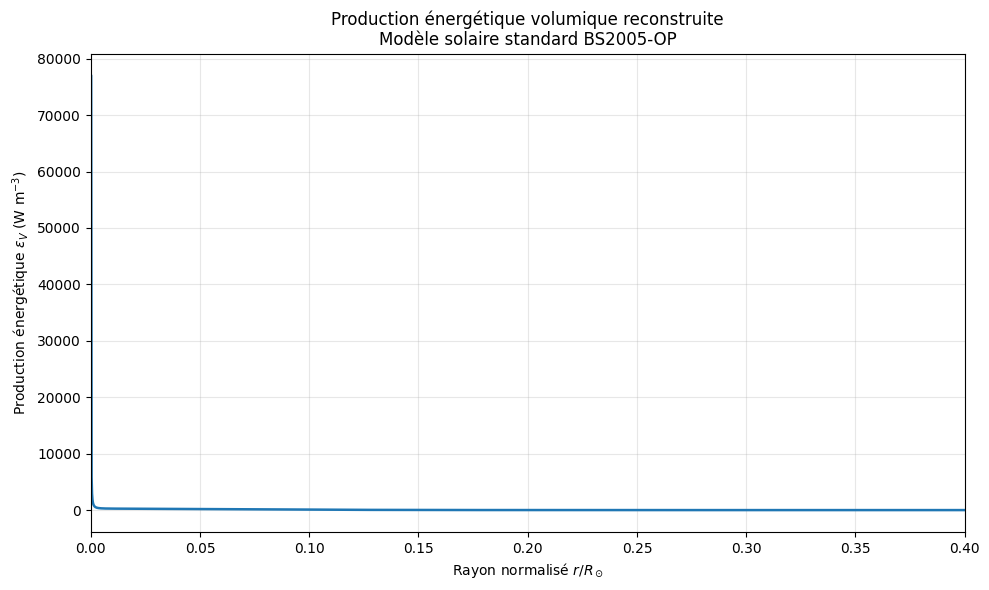

In [ ]:
# ============================================================
# 16. Visualisation du profil énergétique solaire
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    solar_regular["R_frac"],
    solar_regular["epsilon_V_W_m3"],
    linewidth=1.8,
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(r"Production énergétique $\epsilon_V$ (W m$^{-3}$)")
plt.title(
    "Production énergétique volumique reconstruite\n"
    "Modèle solaire standard BS2005-OP"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

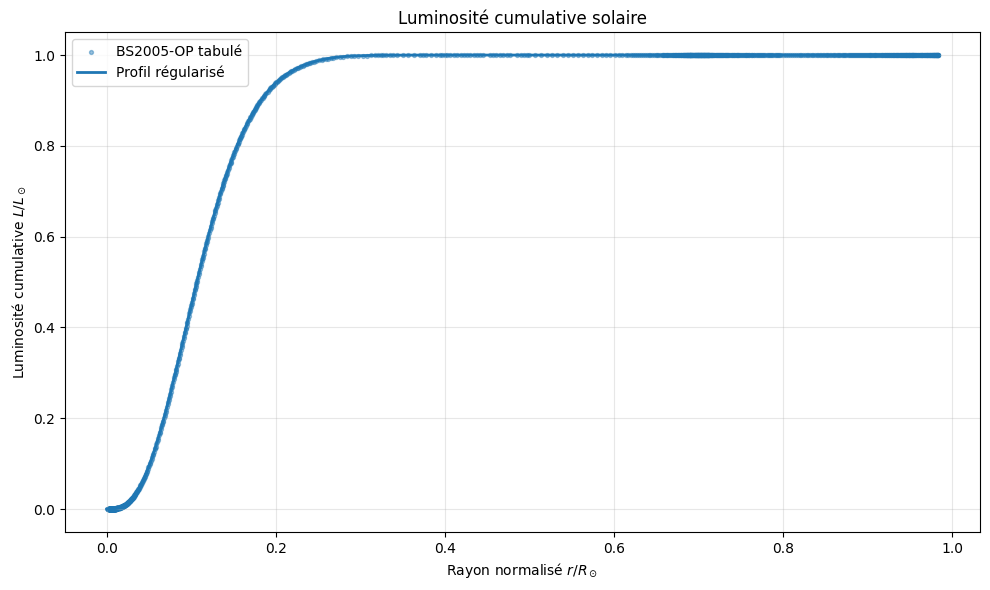

In [ ]:
# ============================================================
# 17. Vérification de la luminosité cumulative
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    x_raw,
    ell_raw,
    s=8,
    alpha=0.45,
    label="BS2005-OP tabulé",
)

plt.plot(
    x_grid,
    ell_smooth,
    linewidth=2.0,
    label="Profil régularisé",
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(r"Luminosité cumulative $L/L_\odot$")
plt.title("Luminosité cumulative solaire")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 18. Reconstruction énergétique dans la coordonnée de masse

La reconstruction directe par la relation

\[
\epsilon_V(r)
=
\frac{1}{4\pi r^2}\frac{dL}{dr}
\]

est numériquement délicate près du centre solaire, car elle implique une division
par \(r^2\).

Le modèle BS2005-OP fournit également la masse intérieure normalisée :

\[
q=\frac{M(r)}{M_\odot}.
\]

L'équation locale de conservation de l'énergie stellaire s'écrit :

\[
\frac{dL}{dm}=\epsilon_m,
\]

où \(\epsilon_m\) est la production d'énergie par unité de masse.

La production volumique est alors :

\[
\epsilon_V(r)
=
\rho(r)\epsilon_m(r)
=
\rho(r)
\frac{L_\odot}{M_\odot}
\frac{d(L/L_\odot)}{d(M/M_\odot)}.
\]

Cette formulation évite la singularité géométrique apparente au centre et
constitue la reconstruction de référence du benchmark.

In [ ]:
# ============================================================
# 19. Préparation des profils dans la coordonnée de masse
# ============================================================

from scipy.interpolate import PchipInterpolator
from scipy.ndimage import gaussian_filter1d

# Masse solaire adoptée
M_SUN_KG = 1.98847e30

q_raw = solar["M_frac"].to_numpy(dtype=float)
x_raw = solar["R_frac"].to_numpy(dtype=float)
ell_raw = solar["L_frac"].to_numpy(dtype=float)
rho_raw = solar["rho_kg_m3"].to_numpy(dtype=float)

# Ajout du centre physique
q_center = np.concatenate(([0.0], q_raw))
x_center = np.concatenate(([0.0], x_raw))
ell_center = np.concatenate(([0.0], ell_raw))
rho_center = np.concatenate(([rho_raw[0]], rho_raw))

# Imposition de la monotonie cumulative de L
ell_center = np.maximum.accumulate(ell_center)

# Suppression d'éventuels doublons dans la coordonnée de masse
q_unique, unique_indices = np.unique(
    q_center,
    return_index=True,
)

x_unique = x_center[unique_indices]
ell_unique = ell_center[unique_indices]
rho_unique = rho_center[unique_indices]

print(f"Nombre de points uniques en masse : {len(q_unique)}")
print(f"Masse minimale                   : {q_unique.min():.6e}")
print(f"Masse maximale                   : {q_unique.max():.8f}")
print(f"Luminosité finale                : {ell_unique[-1]:.8f}")

Nombre de points uniques en masse : 1269
Masse minimale                   : 0.000000e+00
Masse maximale                   : 0.99998970
Luminosité finale                : 1.00007000


In [ ]:
# ============================================================
# 20. Interpolation régulière dans q = M/M_sun
# ============================================================

N_MASS = 10000

q_grid = np.linspace(
    0.0,
    q_unique.max(),
    N_MASS,
)

luminosity_mass_interpolator = PchipInterpolator(
    q_unique,
    ell_unique,
    extrapolate=False,
)

radius_mass_interpolator = PchipInterpolator(
    q_unique,
    x_unique,
    extrapolate=False,
)

density_mass_interpolator = PchipInterpolator(
    q_unique,
    rho_unique,
    extrapolate=False,
)

ell_q = luminosity_mass_interpolator(q_grid)
x_q = radius_mass_interpolator(q_grid)
rho_q = density_mass_interpolator(q_grid)

if (
    np.any(~np.isfinite(ell_q))
    or np.any(~np.isfinite(x_q))
    or np.any(~np.isfinite(rho_q))
):
    raise RuntimeError(
        "Une interpolation dans la coordonnée de masse "
        "contient des valeurs non finies."
    )

ell_q = np.clip(ell_q, 0.0, 1.0)
rho_q = np.clip(rho_q, 0.0, None)

print("Interpolation en masse terminée.")
print(f"Nombre de points : {len(q_grid)}")
print(f"Rayon final      : {x_q[-1]:.5f} R_sun")

Interpolation en masse terminée.
Nombre de points : 10000
Rayon final      : 0.98338 R_sun


In [ ]:
# ============================================================
# 21. Production énergétique volumique via dL/dM
# ============================================================

MASS_SMOOTH_SIGMA = 15.0

ell_q_smooth = gaussian_filter1d(
    ell_q,
    sigma=MASS_SMOOTH_SIGMA,
    mode="nearest",
)

# Conditions cumulatives physiques
ell_q_smooth[0] = 0.0
ell_q_smooth = np.maximum.accumulate(ell_q_smooth)
ell_q_smooth = np.clip(ell_q_smooth, 0.0, 1.0)

# Dérivée normalisée d(L/L_sun)/d(M/M_sun)
dell_dq = np.gradient(
    ell_q_smooth,
    q_grid,
    edge_order=2,
)

# La production nucléaire locale ne doit pas être négative
dell_dq_positive = np.clip(
    dell_dq,
    0.0,
    None,
)

# Production spécifique : W/kg
epsilon_mass_W_kg = (
    L_SUN_W
    / M_SUN_KG
    * dell_dq_positive
)

# Production volumique : W/m³
epsilon_volume_mass_W_m3 = (
    rho_q
    * epsilon_mass_W_kg
)

stellar_mass_profile = pd.DataFrame(
    {
        "M_frac": q_grid,
        "R_frac": x_q,
        "rho_kg_m3": rho_q,
        "L_frac_interp": ell_q,
        "L_frac_smooth": ell_q_smooth,
        "dLfrac_dMfrac": dell_dq_positive,
        "epsilon_mass_W_kg": epsilon_mass_W_kg,
        "epsilon_V_W_m3": epsilon_volume_mass_W_m3,
    }
)

# Classement radial
stellar_mass_profile = (
    stellar_mass_profile
    .sort_values("R_frac")
    .reset_index(drop=True)
)

epsilon_array = stellar_mass_profile[
    "epsilon_V_W_m3"
].to_numpy()

max_index = int(np.argmax(epsilon_array))

print("Reconstruction par la masse terminée.")
print(f"Sigma de lissage      : {MASS_SMOOTH_SIGMA:.1f}")
print(
    "epsilon_V maximale   : "
    f"{epsilon_array[max_index]:.6e} W/m³"
)
print(
    "Position du maximum  : "
    f"{stellar_mass_profile.loc[max_index, 'R_frac']:.6e} R_sun"
)
print(
    "Valeur centrale      : "
    f"{epsilon_array[0]:.6e} W/m³"
)

display(stellar_mass_profile.head(15))

Reconstruction par la masse terminée.
Sigma de lissage      : 15.0
epsilon_V maximale   : 2.315994e+03 W/m³
Position du maximum  : 0.000000e+00 R_sun
Valeur centrale      : 2.315994e+03 W/m³


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,M_frac,R_frac,rho_kg_m3,L_frac_interp,L_frac_smooth,dLfrac_dMfrac,epsilon_mass_W_kg,epsilon_V_W_m3
0,0.0000,0.000000,152900.000000,0.000000,0.000000,78.399669,0.015147,2315.993975
1,0.0001,0.009747,151900.000000,0.000849,0.005375,29.095093,0.005621,853.872893
2,0.0002,0.012289,151200.000000,0.001694,0.005820,4.549594,0.000879,132.904634
3,0.0003,0.014072,150700.000000,0.002533,0.006285,4.761763,0.000920,138.642606
4,0.0004,0.015497,150200.000000,0.003371,0.006772,4.970649,0.000960,144.244336
5,0.0005,0.016707,149800.000000,0.004198,0.007279,5.175352,0.001000,149.784700
6,0.0006,0.017762,149352.528233,0.005038,0.007807,5.375022,0.001038,155.098844
7,0.0007,0.018715,148999.757047,0.005865,0.008355,5.568872,0.001076,160.312901
8,0.0008,0.019570,148600.000000,0.006700,0.008921,5.756183,0.001112,165.260532
9,0.0009,0.020366,148297.820257,0.007527,0.009506,5.936319,0.001147,170.085674


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


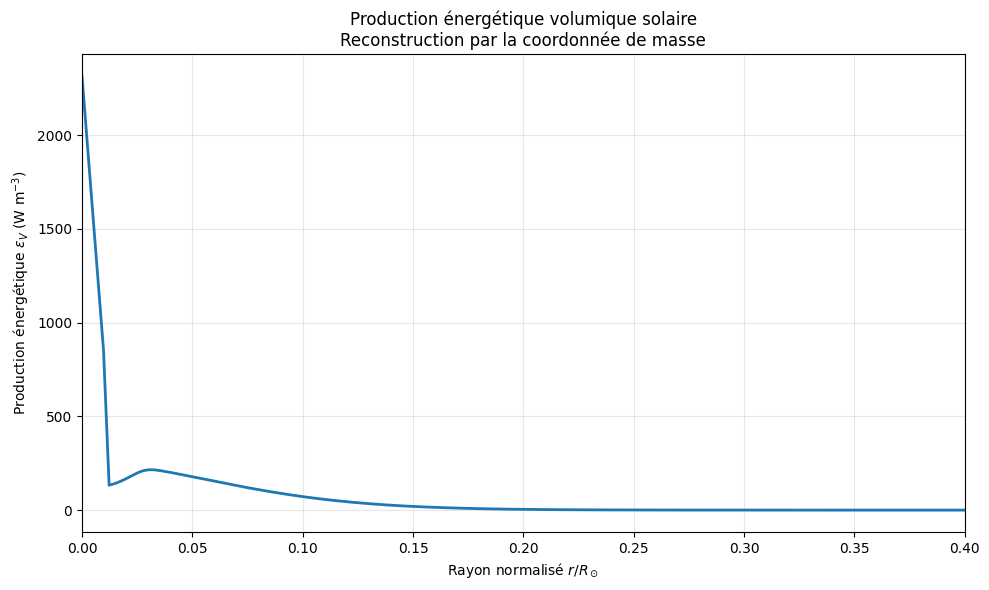

In [ ]:
# ============================================================
# 22. Profil énergétique reconstruit dans la coordonnée de masse
# ============================================================

core_profile = stellar_mass_profile[
    stellar_mass_profile["R_frac"] <= 0.40
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    core_profile["R_frac"],
    core_profile["epsilon_V_W_m3"],
    linewidth=2.0,
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(
    r"Production énergétique $\epsilon_V$ "
    r"(W m$^{-3}$)"
)
plt.title(
    "Production énergétique volumique solaire\n"
    "Reconstruction par la coordonnée de masse"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

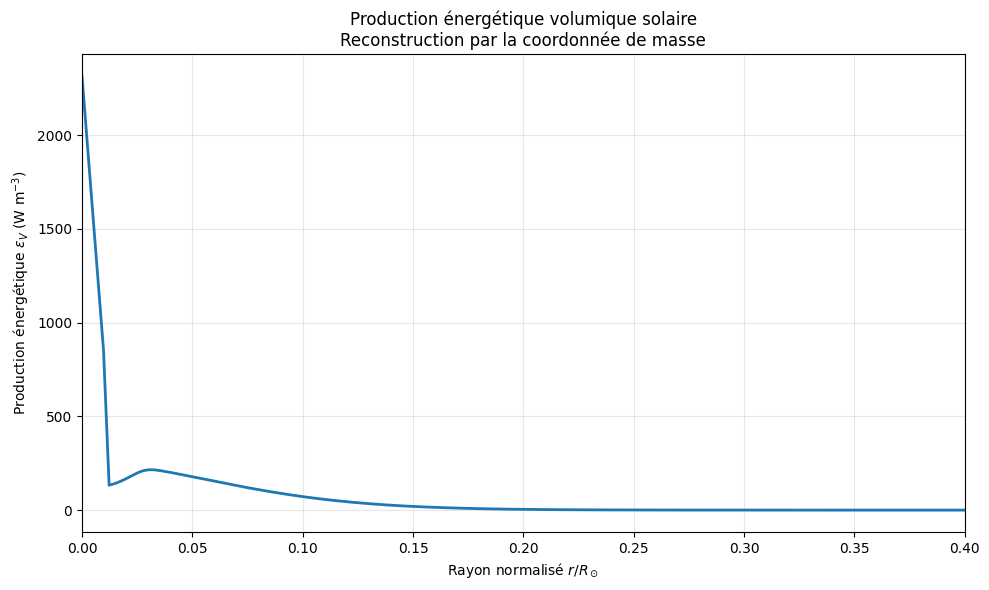

In [ ]:
# ============================================================
# 22. Profil énergétique reconstruit dans la coordonnée de masse
# ============================================================

core_profile = stellar_mass_profile[
    stellar_mass_profile["R_frac"] <= 0.40
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    core_profile["R_frac"],
    core_profile["epsilon_V_W_m3"],
    linewidth=2.0,
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(
    r"Production énergétique $\epsilon_V$ "
    r"(W m$^{-3}$)"
)
plt.title(
    "Production énergétique volumique solaire\n"
    "Reconstruction par la coordonnée de masse"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

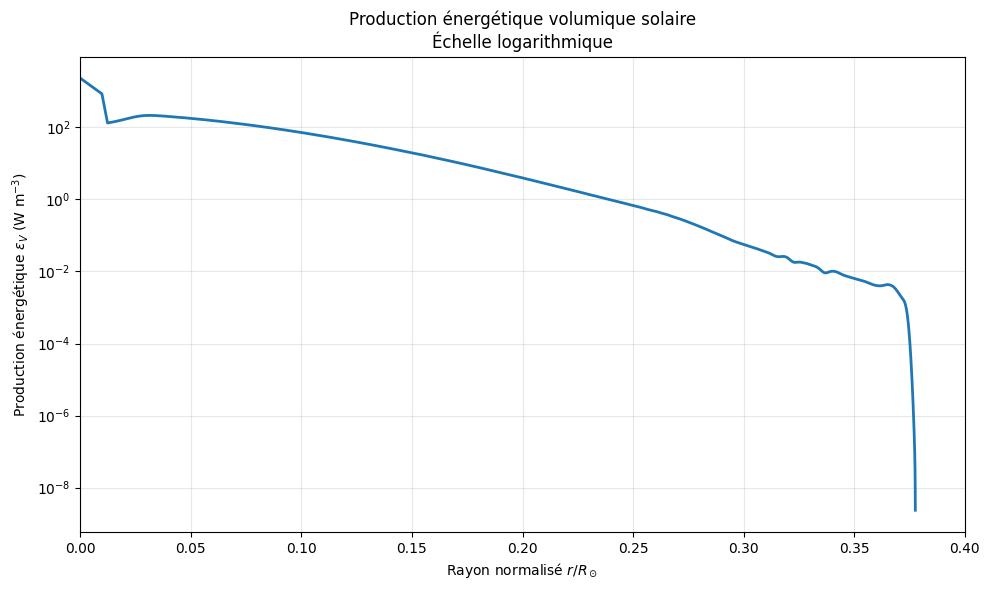

In [ ]:
# ============================================================
# 23. Profil énergétique en échelle logarithmique
# ============================================================

positive_core = core_profile[
    core_profile["epsilon_V_W_m3"] > 0
].copy()

plt.figure(figsize=(10, 6))

plt.semilogy(
    positive_core["R_frac"],
    positive_core["epsilon_V_W_m3"],
    linewidth=2.0,
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(
    r"Production énergétique $\epsilon_V$ "
    r"(W m$^{-3}$)"
)
plt.title(
    "Production énergétique volumique solaire\n"
    "Échelle logarithmique"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 24. Limite de la reconstruction à partir de BS2005-OP

Le profil cumulatif \(L/L_\odot\) du modèle BS2005-OP est tabulé avec une
précision limitée.

La dérivation numérique, même après interpolation et régularisation, produit
une valeur centrale fortement dépendante :

- de la résolution de la grille ;
- de la largeur de lissage ;
- du traitement de la condition au bord \(q=0\).

La pointe centrale obtenue ne peut donc pas être considérée comme une mesure
robuste de la production nucléaire locale.

Le modèle BS2005-OP sera conservé comme référence pour :

\[
T(r),\quad \rho(r),\quad P(r),\quad L(r)
\]

et les fractions chimiques.

Pour l'observable énergétique principale, le benchmark utilisera un modèle
YREC fournissant directement la colonne :

\[
\epsilon_{\rm nuc}(r),
\]

notée dans le fichier **Nuc Reac Rate (Eps)**.

Cette séparation évite de reconstruire une dérivée locale à partir d'une
luminosité cumulative arrondie.

In [ ]:
# ============================================================
# 25. Téléchargement du modèle solaire YREC
# ============================================================

from pathlib import Path
from urllib.request import urlretrieve

YREC_URL = (
    "http://www.ap.smu.ca/~guenther/evolution/"
    "ssmyz47_0200.txt"
)

YREC_FILE = Path("ssmyz47_0200.txt")

try:
    urlretrieve(YREC_URL, YREC_FILE)
except Exception as exc:
    raise RuntimeError(
        "Le téléchargement du modèle YREC a échoué. "
        "Le serveur peut refuser les connexions HTTP depuis Colab."
    ) from exc

if not YREC_FILE.exists():
    raise FileNotFoundError(
        f"Le fichier YREC attendu n'existe pas : {YREC_FILE}"
    )

print("Téléchargement YREC terminé.")
print(f"Fichier : {YREC_FILE.resolve()}")
print(f"Taille  : {YREC_FILE.stat().st_size:,} octets")

Téléchargement YREC terminé.
Fichier : /content/ssmyz47_0200.txt
Taille  : 208,975 octets


In [ ]:
# ============================================================
# 26. Inspection du fichier YREC brut
# ============================================================

with YREC_FILE.open(
    "r",
    encoding="utf-8",
    errors="replace",
) as file:
    yrec_lines = file.readlines()

print(f"Nombre total de lignes : {len(yrec_lines)}")
print()

for index, line in enumerate(yrec_lines[:120], start=1):
    print(f"{index:03d} | {line.rstrip()}")

Nombre total de lignes : 1919

001 | 
002 | YREC6 calculation
003 | G=6.672590E-08 GAS=8.314510E+07 a=7.5640E-15 c=2.99792458E+10 sigma=5.670510E-05
004 |  Model Number............   50
005 |  Mass.................... 1.989100000E+33 gm (   1.00000000000 Msun)
006 |  Radius.................. 6.959801296E+10 cm (   1.00000018628 Rsun)
007 |  Teff....................    5779.630 K
008 |  Luminosity.............. 3.851499859E+33 erg/s (    .99999996339 Lsun)
009 |  Age.....................     4.70000 Gyr
010 |  Mixing length...........   2.10721374590
011 |  X.......................    .70791257700
012 |  Z.......................    .02000000000
013 |  Delta Nu................    137.3035 microHz
014 |  No. interior pts........  617
015 |  No. envelope points.....  725
016 |  No. atmosphere points...  552
017 |  Total number shells..... 1892
018 |  ----------------------------------------------------------------------------------------------------------------------------------
019 |  SHE

In [ ]:
# ============================================================
# 27. Recherche des en-têtes physiques dans le fichier YREC
# ============================================================

keywords = [
    "Radius",
    "Temperature",
    "Density",
    "Luminosity",
    "Nuc Reac",
    "Eps",
]

for keyword in keywords:
    matches = []

    for line_number, line in enumerate(
        yrec_lines,
        start=1,
    ):
        if keyword.lower() in line.lower():
            matches.append(
                (line_number, line.rstrip())
            )

    print(f"\nMot-clé : {keyword}")

    if matches:
        for line_number, content in matches[:10]:
            print(f"  ligne {line_number:04d} | {content}")
    else:
        print("  aucune occurrence")


Mot-clé : Radius
  ligne 0006 |  Radius.................. 6.959801296E+10 cm (   1.00000018628 Rsun)
  ligne 0019 |  SHELL  Radius Frac     Mass Frac       Radius          Mass            Luminosity      Temperature     Density

Mot-clé : Temperature
  ligne 0019 |  SHELL  Radius Frac     Mass Frac       Radius          Mass            Luminosity      Temperature     Density

Mot-clé : Density
  ligne 0019 |  SHELL  Radius Frac     Mass Frac       Radius          Mass            Luminosity      Temperature     Density

Mot-clé : Luminosity
  ligne 0008 |  Luminosity.............. 3.851499859E+33 erg/s (    .99999996339 Lsun)
  ligne 0019 |  SHELL  Radius Frac     Mass Frac       Radius          Mass            Luminosity      Temperature     Density

Mot-clé : Nuc Reac
  ligne 0020 |         Pressure        Cv              Cp              Gamma1          Mean Mol  Wt    Sound Speed     Nuc Reac Rate (Eps)

Mot-clé : Eps
  ligne 0020 |         Pressure        Cv              Cp        

## 28. Lecture structurée du modèle solaire YREC

Le fichier YREC utilise un format multi-lignes.

Chaque coquille stellaire est représentée par un bloc de cinq lignes contenant
au total 34 variables :

1. numéro de coquille ;
2. rayon normalisé ;
3. masse normalisée ;
4. rayon en centimètres ;
5. masse intérieure en grammes ;
6. luminosité intérieure en \(\mathrm{erg\,s^{-1}}\) ;
7. température en kelvins ;
8. densité en \(\mathrm{g\,cm^{-3}}\) ;
9. pression ;
10. capacités thermiques et variables thermodynamiques ;
11. vitesse du son ;
12. taux local de réaction nucléaire \(Eps\) ;
13. composition chimique ;
14. opacité et gradients ;
15. fréquences caractéristiques ;
16. grandeurs liées à la convection.

La variable énergétique principale est :

\[
\epsilon_m(r)=\mathrm{Nuc\ Reac\ Rate\ (Eps)},
\]

exprimée en production d'énergie par unité de masse.

La production volumique est obtenue par :

\[
\epsilon_V(r)=\rho(r)\epsilon_m(r).
\]

In [ ]:
# ============================================================
# 29. Lecture corrigée des blocs YREC
# ============================================================

import re
import numpy as np
import pandas as pd

number_pattern = re.compile(
    r"[+-]?(?:\d+\.\d*|\.\d+|\d+)(?:[Ee][+-]?\d+)?"
)

records = []
block_diagnostics = []

# Le premier bloc commence à la ligne 25
# Ligne 25 -> indice Python 24
start_index = 24
index = start_index

EXPECTED_COUNTS = [8, 7, 7, 6, 5]

while index + 4 < len(yrec_lines):
    block_lines = yrec_lines[index:index + 5]

    values_per_line = [
        [
            float(value)
            for value in number_pattern.findall(line)
        ]
        for line in block_lines
    ]

    counts = [
        len(values)
        for values in values_per_line
    ]

    if counts == EXPECTED_COUNTS:
        flattened = [
            value
            for line_values in values_per_line
            for value in line_values
        ]

        records.append(flattened)
        index += 5

    else:
        block_diagnostics.append(
            {
                "line_number": index + 1,
                "counts": counts,
                "first_line": block_lines[0].rstrip(),
            }
        )
        index += 1

print(f"Blocs YREC valides détectés : {len(records)}")
print(f"Segments ignorés            : {len(block_diagnostics)}")

if len(records) == 0:
    print("\nPremiers diagnostics :")
    for diagnostic in block_diagnostics[:10]:
        print(diagnostic)

    raise RuntimeError(
        "Aucun bloc YREC valide n'a été détecté."
    )

record_lengths = sorted(
    set(len(record) for record in records)
)

print(f"Tailles de blocs détectées   : {record_lengths}")

if record_lengths != [33]:
    raise RuntimeError(
        "Les blocs YREC ne contiennent pas tous 33 variables."
    )

print("\nPremier bloc extrait :")
print(records[0])

Blocs YREC valides détectés : 379
Segments ignorés            : 0
Tailles de blocs détectées   : [33]

Premier bloc extrait :
[1.0, 0.00113911231, 1.64070004e-07, 79279953.5, 3.26351645e+26, 5.65898042e+27, 15798100.1, 156.353294, 2.38353869e+17, 144302116.0, 237442637.0, 1.66786341, 0.862209258, 50424061.7, 17.9099351, 0.328236653, 0.0210971719, 1.26956768, 0.362728115, -1.95223862, 0.332192853, 0.396718699, 1.01361838, 0.989125537, 1.00607987, 12.1156834, 0.809056541, 1.43272575e-08, 0.809034242, 1.43276523e-08, 0.0, 440009138000.0, 0.0]


In [ ]:
# ============================================================
# 30. Construction corrigée du DataFrame YREC
# ============================================================

yrec_columns = [
    # Ligne 1 — 8 valeurs
    "shell",
    "radius_frac",
    "mass_frac",
    "radius_cm",
    "mass_g",
    "luminosity_erg_s",
    "temperature_K",
    "density_g_cm3",

    # Ligne 2 — 7 valeurs
    "pressure_dyn_cm2",
    "Cv",
    "Cp",
    "gamma1",
    "mean_molecular_weight",
    "sound_speed_cm_s",
    "eps_nuc_erg_g_s",

    # Ligne 3 — 7 valeurs
    "X",
    "Z",
    "opacity",
    "d_kappa_d_lnrho",
    "d_kappa_d_lnT",
    "temperature_gradient",
    "adiabatic_temperature_gradient",

    # Ligne 4 — 6 valeurs
    "d_lnP_d_lnrho",
    "d_lnP_d_lnT",
    "d_lneps_d_lnrho",
    "d_lneps_d_lnT",
    "squared_lamb_frequency",
    "squared_brunt_vaisala_frequency",

    # Ligne 5 — 5 valeurs
    "squared_critical_frequency_plus",
    "squared_critical_frequency_minus",
    "alpha",
    "pressure_scale_height_cm",
    "mixing_length",
]

if len(yrec_columns) != 33:
    raise RuntimeError(
        f"Nombre incorrect de noms : {len(yrec_columns)}"
    )

yrec = pd.DataFrame(
    records,
    columns=yrec_columns,
)

# La coquille est un identifiant entier
yrec["shell"] = yrec["shell"].astype(int)

# Nettoyage
yrec = (
    yrec
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "radius_frac",
            "mass_frac",
            "temperature_K",
            "density_g_cm3",
            "eps_nuc_erg_g_s",
        ]
    )
    .sort_values("radius_frac")
    .drop_duplicates(subset="radius_frac")
    .reset_index(drop=True)
)

print("Dimensions du tableau YREC :", yrec.shape)
print(
    "Intervalle radial          : "
    f"{yrec['radius_frac'].min():.6e} à "
    f"{yrec['radius_frac'].max():.6e} R_sun"
)
print(
    "Intervalle de Eps          : "
    f"{yrec['eps_nuc_erg_g_s'].min():.6e} à "
    f"{yrec['eps_nuc_erg_g_s'].max():.6e} erg g⁻¹ s⁻¹"
)

display(yrec.head())
display(yrec.tail())

Dimensions du tableau YREC : (379, 33)
Intervalle radial          : 1.139112e-03 à 1.001182e+00 R_sun
Intervalle de Eps          : 0.000000e+00 à 1.790994e+01 erg g⁻¹ s⁻¹


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,shell,radius_frac,mass_frac,radius_cm,mass_g,luminosity_erg_s,temperature_K,density_g_cm3,pressure_dyn_cm2,Cv,Cp,gamma1,mean_molecular_weight,sound_speed_cm_s,eps_nuc_erg_g_s,X,Z,opacity,d_kappa_d_lnrho,d_kappa_d_lnT,temperature_gradient,adiabatic_temperature_gradient,d_lnP_d_lnrho,d_lnP_d_lnT,d_lneps_d_lnrho,d_lneps_d_lnT,squared_lamb_frequency,squared_brunt_vaisala_frequency,squared_critical_frequency_plus,squared_critical_frequency_minus,alpha,pressure_scale_height_cm,mixing_length
0,1,0.001139,1.640700e-07,79279953.5,3.263516e+26,5.658980e+27,15798100.1,156.353294,2.383539e+17,144302116.0,237442637.0,1.667863,0.862209,50424061.7,17.909935,0.328237,0.021097,1.269568,0.362728,-1.952239,0.332193,0.396719,1.013618,0.989126,1.006080,12.115683,0.809057,1.432726e-08,0.809034,1.432765e-08,0.0,4.400091e+11,0.0
1,6,0.001548,4.121252e-07,107770737.0,8.197583e+26,1.423849e+28,15797698.3,156.339167,2.383356e+17,144307850.0,237452201.0,1.667863,0.862175,50424411.4,17.908241,0.328274,0.021098,1.269642,0.362733,-1.952229,0.332776,0.396719,1.013618,0.989126,1.006081,12.115221,0.437834,2.596529e-08,0.437791,2.596784e-08,0.0,3.237000e+11,0.0
2,11,0.002105,1.035212e-06,146503236.0,2.059140e+27,3.578624e+28,15796955.1,156.313083,2.383020e+17,144318436.0,237469857.0,1.667863,0.862113,50425054.6,17.904914,0.328342,0.021098,1.269717,0.362744,-1.952190,0.333005,0.396719,1.013617,0.989127,1.006082,12.114296,0.236935,4.795292e-08,0.236891,4.796166e-08,0.0,2.381477e+11,0.0
3,16,0.002862,2.600334e-06,199162130.0,5.172325e+27,8.989766e+28,15795581.1,156.264899,2.382397e+17,144337999.0,237502489.0,1.667863,0.861997,50426242.4,17.898776,0.328468,0.021098,1.269859,0.362765,-1.952120,0.333096,0.396719,1.013615,0.989129,1.006085,12.112592,0.128212,8.857285e-08,0.128169,8.860265e-08,0.0,1.752210e+11,0.0
4,21,0.003890,6.531745e-06,270763034.0,1.299229e+28,2.257541e+29,15793042.1,156.175921,2.381248e+17,144374142.0,237562774.0,1.667863,0.861783,50428433.9,17.887436,0.328702,0.021097,1.270122,0.362803,-1.951990,0.333132,0.396720,1.013611,0.989133,1.006089,12.109447,0.069375,1.635476e-07,0.069332,1.636493e-07,0.0,1.289404e+11,0.0


,shell,radius_frac,mass_frac,radius_cm,mass_g,luminosity_erg_s,temperature_K,density_g_cm3,pressure_dyn_cm2,Cv,Cp,gamma1,mean_molecular_weight,sound_speed_cm_s,eps_nuc_erg_g_s,X,Z,opacity,d_kappa_d_lnrho,d_kappa_d_lnT,temperature_gradient,adiabatic_temperature_gradient,d_lnP_d_lnrho,d_lnP_d_lnT,d_lneps_d_lnrho,d_lneps_d_lnT,squared_lamb_frequency,squared_brunt_vaisala_frequency,squared_critical_frequency_plus,squared_critical_frequency_minus,alpha,pressure_scale_height_cm,mixing_length
374,1871,1.001115,1.0,6.967565e+10,1.989100e+33,3.851500e+33,4631.88724,2.104860e-10,64.029850,112144224.0,186581994.0,1.633576,1.289381,704935.380,0.0,0.740335,0.01797,0.000860,0.541004,7.104380,9.133200e-07,0.378185,0.981853,1.054919,0.0,0.0,2.047230e-10,0.003995,0.001045,7.823272e-10,0.0,11126798.9,0.0
375,1876,1.001131,1.0,6.967673e+10,1.989100e+33,3.851500e+33,4631.88578,1.907045e-10,58.121496,113710664.0,189218455.0,1.630770,1.289379,704992.037,0.0,0.740335,0.01797,0.000816,0.521627,7.342958,7.866870e-07,0.376293,0.980010,1.060479,0.0,0.0,2.047495e-10,0.003993,0.001046,7.818647e-10,0.0,11148085.8,0.0
376,1881,1.001147,1.0,6.967786e+10,1.989100e+33,3.851500e+33,4631.88449,1.721252e-10,52.572205,115512056.0,192258508.0,1.627620,1.289376,705070.184,0.0,0.740335,0.01797,0.000774,0.501068,7.586216,6.752365e-07,0.374174,0.977901,1.066840,0.0,0.0,2.047883e-10,0.003990,0.001046,7.813567e-10,0.0,11172498.3,0.0
377,1886,1.001164,1.0,6.967903e+10,1.989100e+33,3.851500e+33,4631.88333,1.546754e-10,47.360278,117600056.0,195793695.0,1.624070,1.289373,705178.343,0.0,0.740335,0.01797,0.000735,0.479155,7.834902,5.772436e-07,0.371790,0.975470,1.074175,0.0,0.0,2.048442e-10,0.003987,0.001046,7.807985e-10,0.0,11200727.5,0.0
378,1891,1.001182,1.0,6.968027e+10,1.989100e+33,3.851500e+33,4631.88231,1.382869e-10,42.465353,120042635.0,199945394.0,1.620053,1.289370,705328.570,0.0,0.740335,0.01797,0.000697,0.455679,8.089908,4.911814e-07,0.369097,0.972643,1.082703,0.0,0.0,2.049242e-10,0.003984,0.001036,7.883337e-10,0.0,11233683.6,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 30b. Vérification des colonnes essentielles
# ============================================================

essential_columns = [
    "shell",
    "radius_frac",
    "mass_frac",
    "radius_cm",
    "mass_g",
    "luminosity_erg_s",
    "temperature_K",
    "density_g_cm3",
    "pressure_dyn_cm2",
    "sound_speed_cm_s",
    "eps_nuc_erg_g_s",
]

display(
    yrec[essential_columns].head(15)
)

print("\nPremière coquille :")
print(
    f"rayon       = {yrec.loc[0, 'radius_frac']:.8e} R_sun"
)
print(
    f"température = {yrec.loc[0, 'temperature_K']:.8e} K"
)
print(
    f"densité     = {yrec.loc[0, 'density_g_cm3']:.8e} g/cm³"
)
print(
    f"Eps         = {yrec.loc[0, 'eps_nuc_erg_g_s']:.8e} "
    "erg g⁻¹ s⁻¹"
)

,shell,radius_frac,mass_frac,radius_cm,mass_g,luminosity_erg_s,temperature_K,density_g_cm3,pressure_dyn_cm2,sound_speed_cm_s,eps_nuc_erg_g_s
0,1,0.001139,1.640700e-07,7.927995e+07,3.263516e+26,5.658980e+27,15798100.1,156.353294,2.383539e+17,50424061.7,17.909935
1,6,0.001548,4.121252e-07,1.077707e+08,8.197583e+26,1.423849e+28,15797698.3,156.339167,2.383356e+17,50424411.4,17.908241
2,11,0.002105,1.035212e-06,1.465032e+08,2.059140e+27,3.578624e+28,15796955.1,156.313083,2.383020e+17,50425054.6,17.904914
3,16,0.002862,2.600334e-06,1.991621e+08,5.172325e+27,8.989766e+28,15795581.1,156.264899,2.382397e+17,50426242.4,17.898776
4,21,0.003890,6.531745e-06,2.707630e+08,1.299229e+28,2.257541e+29,15793042.1,156.175921,2.381248e+17,50428433.9,17.887436
5,26,0.005290,1.640700e-05,3.681409e+08,3.263516e+28,5.667071e+29,15788350.9,156.011699,2.379125e+17,50432472.7,17.866497
6,31,0.007193,4.121252e-05,5.006294e+08,8.197583e+28,1.421738e+30,15779685.0,155.708909,2.375208e+17,50439899.2,17.827856
7,36,0.009785,1.035212e-04,6.810228e+08,2.059140e+29,3.562972e+30,15763682.2,155.151669,2.367985e+17,50453497.6,17.756633
8,41,0.013319,2.600334e-04,9.269812e+08,5.172325e+29,8.911444e+30,15734146.9,154.129659,2.354692e+17,50478200.8,17.625635
9,46,0.018150,6.531745e-04,1.263183e+09,1.299229e+30,2.220769e+31,15679690.6,152.266987,2.330314e+17,50522404.5,17.385624



Première coquille :
rayon       = 1.13911231e-03 R_sun
température = 1.57981001e+07 K
densité     = 1.56353294e+02 g/cm³
Eps         = 1.79099351e+01 erg g⁻¹ s⁻¹


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 31. Conversion de la production nucléaire en unités SI
# ============================================================

# Conversion de la production spécifique :
# 1 erg g^-1 s^-1 = 1e-4 W kg^-1
yrec["eps_nuc_W_kg"] = (
    yrec["eps_nuc_erg_g_s"] * 1e-4
)

# Conversion de la densité :
# 1 g cm^-3 = 1000 kg m^-3
yrec["density_kg_m3"] = (
    yrec["density_g_cm3"] * 1e3
)

# Production volumique locale
yrec["eps_nuc_W_m3"] = (
    yrec["eps_nuc_W_kg"]
    * yrec["density_kg_m3"]
)

# Autres conversions utiles
yrec["radius_m"] = yrec["radius_cm"] * 1e-2
yrec["mass_kg"] = yrec["mass_g"] * 1e-3
yrec["luminosity_W"] = (
    yrec["luminosity_erg_s"] * 1e-7
)

# Sécurité numérique
yrec["eps_nuc_W_m3"] = np.clip(
    yrec["eps_nuc_W_m3"],
    0.0,
    None,
)

max_index = int(
    yrec["eps_nuc_W_m3"].idxmax()
)

print("Conversion énergétique terminée.")
print(
    "Production volumique première coquille : "
    f"{yrec.loc[0, 'eps_nuc_W_m3']:.6f} W/m³"
)
print(
    "Production volumique maximale          : "
    f"{yrec.loc[max_index, 'eps_nuc_W_m3']:.6f} W/m³"
)
print(
    "Position du maximum                    : "
    f"{yrec.loc[max_index, 'radius_frac']:.8e} R_sun"
)

display(
    yrec[
        [
            "shell",
            "radius_frac",
            "temperature_K",
            "density_g_cm3",
            "eps_nuc_erg_g_s",
            "eps_nuc_W_kg",
            "eps_nuc_W_m3",
        ]
    ].head(20)
)

Conversion énergétique terminée.
Production volumique première coquille : 280.027735 W/m³
Production volumique maximale          : 280.027735 W/m³
Position du maximum                    : 1.13911231e-03 R_sun


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,shell,radius_frac,temperature_K,density_g_cm3,eps_nuc_erg_g_s,eps_nuc_W_kg,eps_nuc_W_m3
0,1,0.001139,15798100.1,156.353294,17.909935,0.001791,280.027735
1,6,0.001548,15797698.3,156.339167,17.908241,0.001791,279.975956
2,11,0.002105,15796955.1,156.313083,17.904914,0.001790,279.877225
3,16,0.002862,15795581.1,156.264899,17.898776,0.001790,279.695036
4,21,0.003890,15793042.1,156.175921,17.887436,0.001789,279.358679
5,26,0.005290,15788350.9,156.011699,17.866497,0.001787,278.738249
6,31,0.007193,15779685.0,155.708909,17.827856,0.001783,277.595598
7,36,0.009785,15763682.2,155.151669,17.756633,0.001776,275.497129
8,41,0.013319,15734146.9,154.129659,17.625635,0.001763,271.663317
9,46,0.018150,15679690.6,152.266987,17.385624,0.001739,264.725663


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


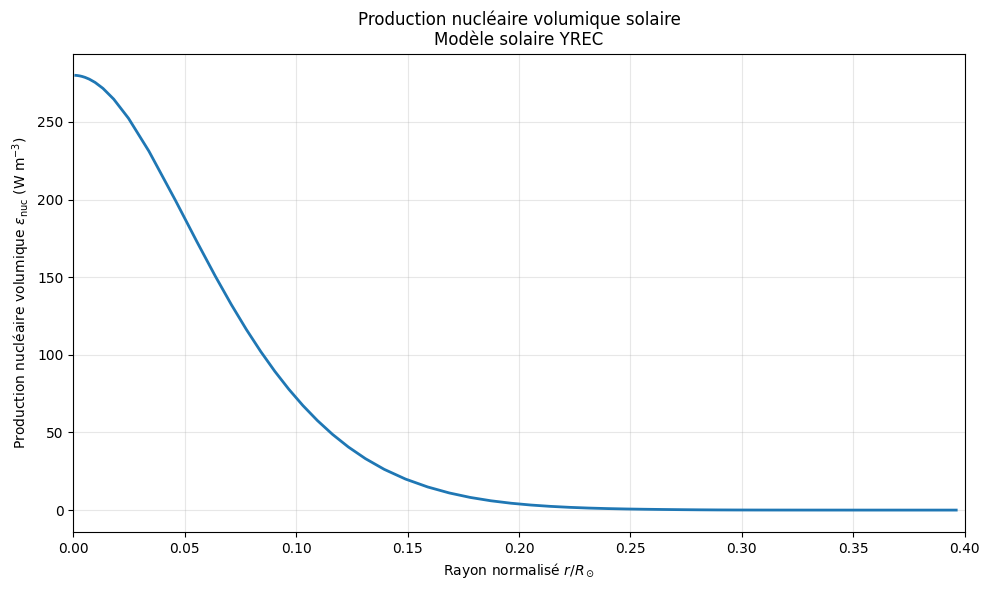

In [ ]:
# ============================================================
# 32. Profil direct de production nucléaire YREC
# ============================================================

yrec_core = yrec[
    yrec["radius_frac"] <= 0.40
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    yrec_core["radius_frac"],
    yrec_core["eps_nuc_W_m3"],
    linewidth=2.0,
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(
    r"Production nucléaire volumique "
    r"$\epsilon_{\rm nuc}$ (W m$^{-3}$)"
)
plt.title(
    "Production nucléaire volumique solaire\n"
    "Modèle solaire YREC"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

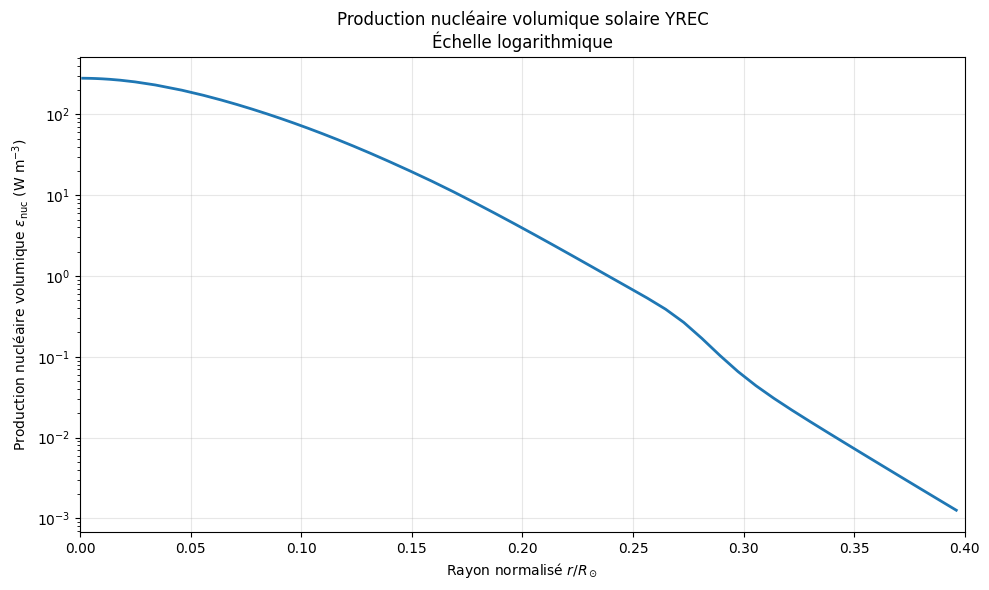

In [ ]:
# ============================================================
# 33. Profil direct en échelle logarithmique
# ============================================================

yrec_core_positive = yrec_core[
    yrec_core["eps_nuc_W_m3"] > 0.0
].copy()

plt.figure(figsize=(10, 6))

plt.semilogy(
    yrec_core_positive["radius_frac"],
    yrec_core_positive["eps_nuc_W_m3"],
    linewidth=2.0,
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(
    r"Production nucléaire volumique "
    r"$\epsilon_{\rm nuc}$ (W m$^{-3}$)"
)
plt.title(
    "Production nucléaire volumique solaire YREC\n"
    "Échelle logarithmique"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 34. Vérification de la luminosité reconstruite
# ============================================================

r_m = yrec["radius_m"].to_numpy(dtype=float)
epsilon_V = yrec["eps_nuc_W_m3"].to_numpy(dtype=float)

integrand = (
    4.0
    * np.pi
    * r_m**2
    * epsilon_V
)

L_reconstructed_W = np.trapezoid(
    integrand,
    r_m,
)

L_model_W = float(
    yrec["luminosity_W"].iloc[-1]
)

relative_error = (
    L_reconstructed_W - L_model_W
) / L_model_W

print("Vérification énergétique")
print("------------------------")
print(
    f"Luminosité reconstruite : {L_reconstructed_W:.6e} W"
)
print(
    f"Luminosité du modèle    : {L_model_W:.6e} W"
)
print(
    f"Écart relatif           : {relative_error:.6%}"
)

Vérification énergétique
------------------------
Luminosité reconstruite : 3.888204e+26 W
Luminosité du modèle    : 3.851500e+26 W
Écart relatif           : 0.952978%


## 35. Construction du profil radial GVH de référence

La production nucléaire volumique directe du modèle YREC est maintenant validée
par conservation énergétique.

L'intégration du profil fournit une luminosité reconstruite qui diffère de moins
de \(1\%\) de la luminosité totale du modèle.

Le profil énergétique de référence est défini par :

\[
x=\frac{r}{R_\odot},
\qquad
E(x)=\epsilon_{\rm nuc}(x),
\]

avec :

\[
0\leq x\leq1.
\]

Pour rendre les observables GVH indépendantes de l'unité physique absolue, le
profil est également normalisé :

\[
u_E(x)=\frac{E(x)}{E_{\max}}.
\]

Le calcul GVH principal utilisera le profil normalisé \(u_E(x)\), tandis que le
profil physique en \(\mathrm{W\,m^{-3}}\) sera conservé pour l'interprétation
astrophysique.

Une interpolation monotone PCHIP est utilisée sur une grille radiale uniforme.
Aucun lissage supplémentaire n'est appliqué au profil YREC direct.

In [ ]:
# ============================================================
# 35. Préparation du profil radial YREC pour GVH
# ============================================================

from scipy.interpolate import PchipInterpolator

# Sélection du domaine solaire physique
yrec_solar = (
    yrec.loc[
        (yrec["radius_frac"] > 0.0)
        & (yrec["radius_frac"] <= 1.0)
    ]
    .sort_values("radius_frac")
    .drop_duplicates(subset="radius_frac")
    .reset_index(drop=True)
)

x_yrec = yrec_solar["radius_frac"].to_numpy(dtype=float)
epsilon_yrec = yrec_solar["eps_nuc_W_m3"].to_numpy(dtype=float)

# Ajout du centre solaire.
# La symétrie sphérique implique une dérivée nulle au centre.
x_source = np.concatenate(([0.0], x_yrec))
epsilon_source = np.concatenate(([epsilon_yrec[0]], epsilon_yrec))

# Ajout explicite de la surface si nécessaire
if x_source[-1] < 1.0:
    x_source = np.append(x_source, 1.0)
    epsilon_source = np.append(epsilon_source, 0.0)

# Sécurité physique
epsilon_source = np.clip(
    epsilon_source,
    a_min=0.0,
    a_max=None,
)

print("Profil source GVH préparé.")
print(f"Nombre de points source : {len(x_source)}")
print(f"Rayon minimal           : {x_source.min():.8f} R_sun")
print(f"Rayon maximal           : {x_source.max():.8f} R_sun")
print(
    "Production maximale    : "
    f"{epsilon_source.max():.6f} W/m³"
)

Profil source GVH préparé.
Nombre de points source : 271
Rayon minimal           : 0.00000000 R_sun
Rayon maximal           : 1.00000000 R_sun
Production maximale    : 280.027735 W/m³


In [ ]:
# ============================================================
# 36. Interpolation radiale uniforme
# ============================================================

N_GVH = 5000

x_gvh = np.linspace(
    0.0,
    1.0,
    N_GVH,
)

epsilon_interpolator = PchipInterpolator(
    x_source,
    epsilon_source,
    extrapolate=False,
)

epsilon_gvh = epsilon_interpolator(x_gvh)

if np.any(~np.isfinite(epsilon_gvh)):
    raise RuntimeError(
        "Le profil GVH interpolé contient des valeurs non finies."
    )

epsilon_gvh = np.clip(
    epsilon_gvh,
    a_min=0.0,
    a_max=None,
)

epsilon_max = float(np.max(epsilon_gvh))

if epsilon_max <= 0.0:
    raise RuntimeError(
        "La production énergétique maximale doit être positive."
    )

# Profil énergétique normalisé
u_epsilon = epsilon_gvh / epsilon_max

gvh_solar_profile = pd.DataFrame(
    {
        "R_frac": x_gvh,
        "r_m": x_gvh * 6.959801296e8,
        "epsilon_nuc_W_m3": epsilon_gvh,
        "epsilon_nuc_normalized": u_epsilon,
    }
)

print("Grille GVH construite.")
print(f"Nombre de points       : {N_GVH}")
print(f"Pas radial             : {x_gvh[1] - x_gvh[0]:.6e}")
print(f"epsilon maximale       : {epsilon_max:.6f} W/m³")
print(
    "Valeur normalisée min : "
    f"{u_epsilon.min():.6e}"
)
print(
    "Valeur normalisée max : "
    f"{u_epsilon.max():.6e}"
)

display(gvh_solar_profile.head())
display(gvh_solar_profile.tail())

Grille GVH construite.
Nombre de points       : 5000
Pas radial             : 2.000400e-04
epsilon maximale       : 280.027735 W/m³
Valeur normalisée min : 0.000000e+00
Valeur normalisée max : 1.000000e+00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,R_frac,r_m,epsilon_nuc_W_m3,epsilon_nuc_normalized
0,0.0000,0.000000,280.027735,1.0
1,0.0002,139223.870694,280.027735,1.0
2,0.0004,278447.741388,280.027735,1.0
3,0.0006,417671.612082,280.027735,1.0
4,0.0008,556895.482777,280.027735,1.0


,R_frac,r_m,epsilon_nuc_W_m3,epsilon_nuc_normalized
4995,0.9992,6.954232e+08,0.0,0.0
4996,0.9994,6.955625e+08,0.0,0.0
4997,0.9996,6.957017e+08,0.0,0.0
4998,0.9998,6.958409e+08,0.0,0.0
4999,1.0000,6.959801e+08,0.0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


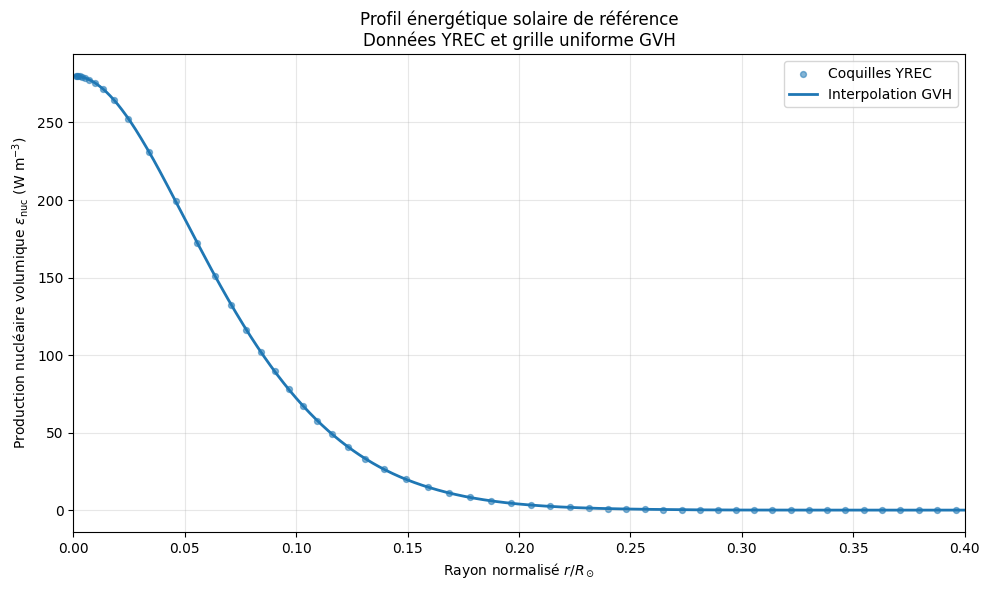

In [ ]:
# ============================================================
# 37. Vérification du profil radial GVH
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    x_yrec,
    epsilon_yrec,
    s=18,
    alpha=0.55,
    label="Coquilles YREC",
)

plt.plot(
    x_gvh,
    epsilon_gvh,
    linewidth=2.0,
    label="Interpolation GVH",
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(
    r"Production nucléaire volumique "
    r"$\epsilon_{\rm nuc}$ (W m$^{-3}$)"
)
plt.title(
    "Profil énergétique solaire de référence\n"
    "Données YREC et grille uniforme GVH"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

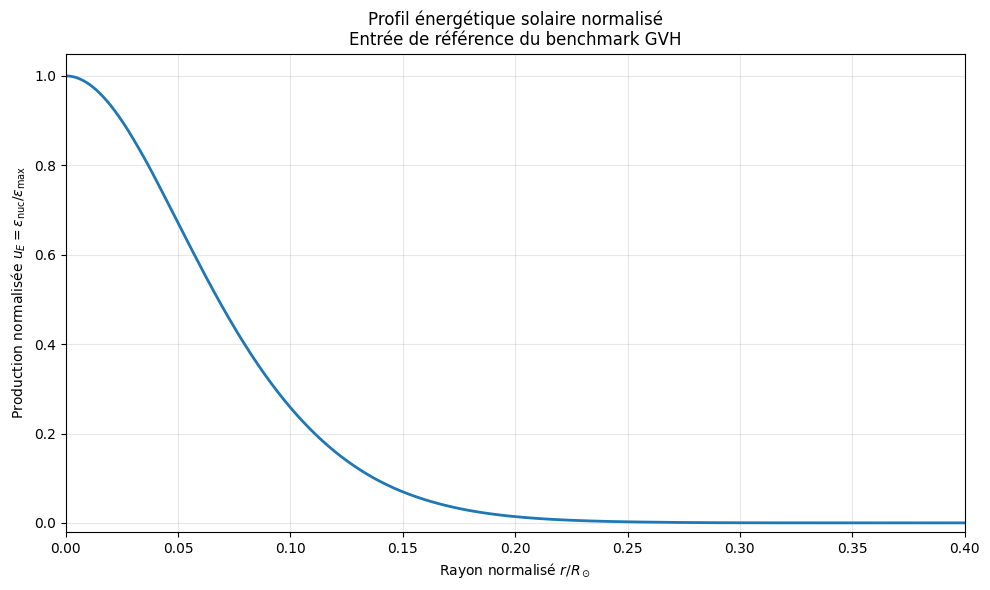

In [ ]:
# ============================================================
# 38. Profil énergétique normalisé
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x_gvh,
    u_epsilon,
    linewidth=2.0,
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(
    r"Production normalisée "
    r"$u_E=\epsilon_{\rm nuc}/\epsilon_{\max}$"
)
plt.title(
    "Profil énergétique solaire normalisé\n"
    "Entrée de référence du benchmark GVH"
)

plt.xlim(0.0, 0.40)
plt.ylim(-0.02, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 39. Définition des observables GVH radiales

Le profil d'entrée du benchmark est :

\[
u_E(x)=\frac{\epsilon_{\rm nuc}(x)}{\epsilon_{\max}},
\qquad
x=\frac{r}{R_\odot}.
\]

L'observable locale fondamentale est définie par :

\[
D_T(x)=\left|\frac{du_E}{dx}\right|.
\]

Elle mesure la variation radiale locale de la production nucléaire normalisée.

Les observables globales sont :

\[
D_{T,\mathrm{mean}}=\langle D_T\rangle,
\]

\[
S_T=\operatorname{std}(D_T),
\]

\[
S_T^{\mathrm{norm}}
=
\frac{S_T}{D_{T,\mathrm{mean}}},
\]

lorsque \(D_{T,\mathrm{mean}}>0\).

Le seuil critique descriptif est fixé au quantile \(95\%\) :

\[
D_c=Q_{0.95}(D_T).
\]

La fraction supercritique est :

\[
R_{\rm super}
=
\frac{1}{N}
\sum_i
\mathbf{1}\!\left(D_{T,i}>D_c\right).
\]

Ces quantités sont d'abord interprétées comme des diagnostics descriptifs du
gradient radial. Elles ne constituent pas encore une preuve d'une transition
GVH fondamentale.

In [ ]:
# ============================================================
# 40. Calcul de D_T et des observables GVH principales
# ============================================================

x = x_gvh.astype(float)
u = u_epsilon.astype(float)

if len(x) != len(u):
    raise ValueError(
        "Les tableaux radial et énergétique doivent avoir la même longueur."
    )

if len(x) < 3:
    raise ValueError(
        "Au moins trois points sont nécessaires pour calculer le gradient."
    )

if np.any(~np.isfinite(x)) or np.any(~np.isfinite(u)):
    raise ValueError(
        "Les données GVH contiennent des valeurs non finies."
    )

if np.any(np.diff(x) <= 0.0):
    raise ValueError(
        "La coordonnée radiale doit être strictement croissante."
    )

# Gradient par rapport au rayon normalisé x = r/R_sun
du_dx = np.gradient(
    u,
    x,
    edge_order=2,
)

D_T = np.abs(du_dx)

# Observables globales
D_T_mean = float(np.mean(D_T))
S_T = float(np.std(D_T, ddof=0))

if D_T_mean > 0.0:
    S_T_norm = S_T / D_T_mean
else:
    S_T_norm = np.nan

# Définition canonique descriptive : quantile 95 %
D_c = float(np.quantile(D_T, 0.95))

# Strictement supérieur au seuil
R_super = float(np.mean(D_T > D_c))

gvh_solar_profile["du_dx"] = du_dx
gvh_solar_profile["D_T"] = D_T
gvh_solar_profile["is_supercritical"] = D_T > D_c

print("Observables GVH radiales")
print("------------------------")
print(f"D_T_mean  = {D_T_mean:.10e}")
print(f"S_T       = {S_T:.10e}")
print(f"S_T_norm  = {S_T_norm:.10e}")
print(f"D_c       = {D_c:.10e}")
print(f"R_super   = {R_super:.10e}")
print(f"R_super % = {100.0 * R_super:.6f} %")

Observables GVH radiales
------------------------
D_T_mean  = 9.9980000000e-01
S_T       = 2.4422154499e+00
S_T_norm  = 2.4427039907e+00
D_c       = 8.1156539684e+00
R_super   = 5.0000000000e-02
R_super % = 5.000000 %


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 41. Localisation de la transition radiale dominante
# ============================================================

max_gradient_index = int(np.argmax(D_T))

x_Dmax = float(x[max_gradient_index])
D_T_max = float(D_T[max_gradient_index])

supercritical_x = x[D_T > D_c]

print("Localisation du gradient")
print("------------------------")
print(f"D_T maximal         = {D_T_max:.10e}")
print(f"Position de D_T max = {x_Dmax:.8f} R_sun")

if len(supercritical_x) > 0:
    print(
        "Zone supercritique    = "
        f"[{supercritical_x.min():.8f}, "
        f"{supercritical_x.max():.8f}] R_sun"
    )
else:
    print("Aucune zone supercritique détectée.")

Localisation du gradient
------------------------
D_T maximal         = 9.9461505415e+00
Position de D_T max = 0.05101020 R_sun
Zone supercritique    = [0.02820564, 0.07801560] R_sun


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


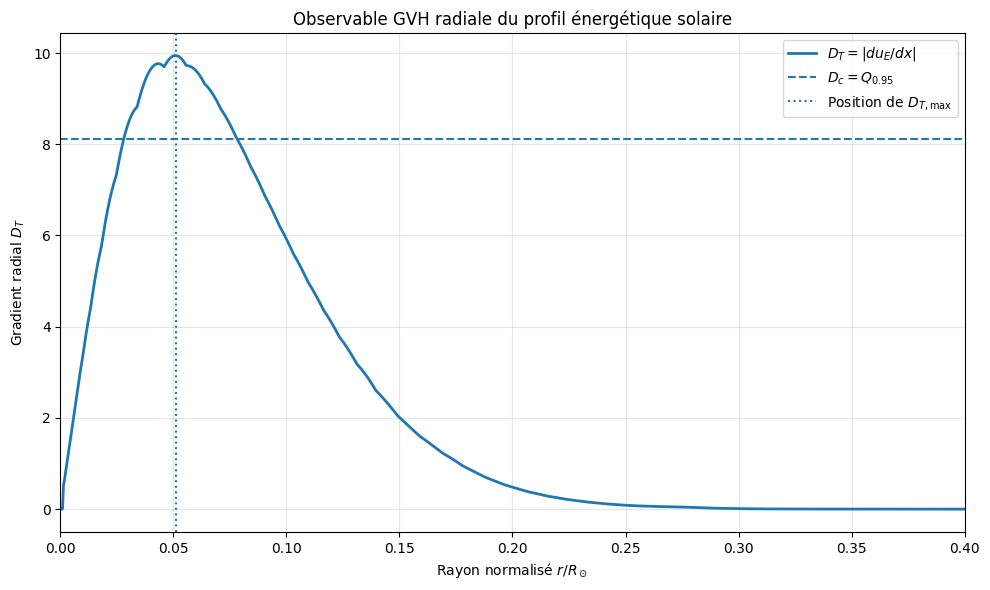

In [ ]:
# ============================================================
# 42. Profil du gradient radial GVH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    D_T,
    linewidth=2.0,
    label=r"$D_T=|du_E/dx|$",
)

plt.axhline(
    D_c,
    linestyle="--",
    linewidth=1.5,
    label=r"$D_c=Q_{0.95}$",
)

plt.axvline(
    x_Dmax,
    linestyle=":",
    linewidth=1.5,
    label=r"Position de $D_{T,\max}$",
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(r"Gradient radial $D_T$")
plt.title(
    "Observable GVH radiale du profil énergétique solaire"
)

plt.xlim(0.0, 0.40)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

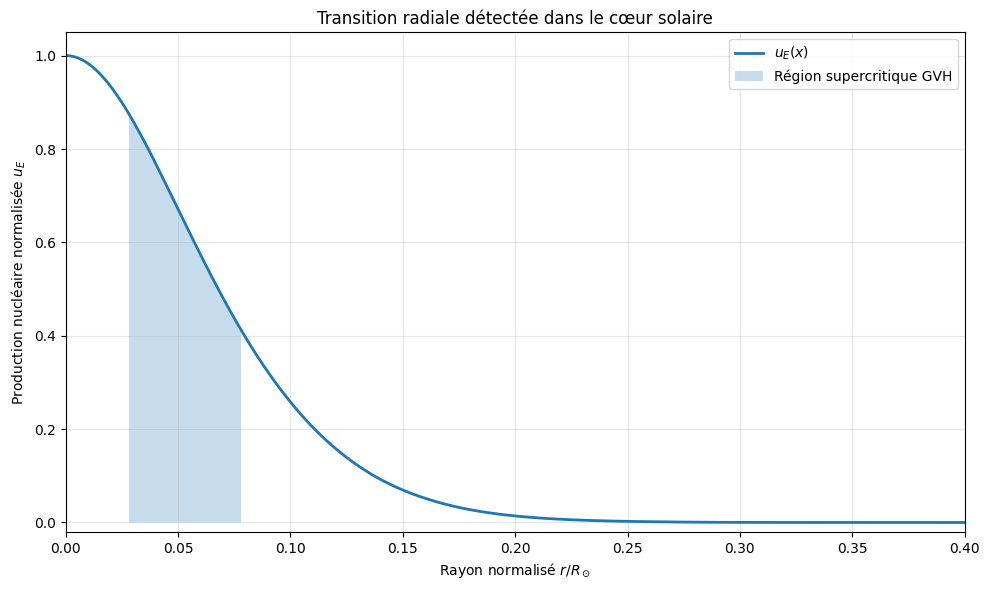

In [ ]:
# ============================================================
# 43. Profil énergétique et région supercritique
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    u,
    linewidth=2.0,
    label=r"$u_E(x)$",
)

supercritical_mask = D_T > D_c

plt.fill_between(
    x,
    0.0,
    u,
    where=supercritical_mask,
    alpha=0.25,
    label="Région supercritique GVH",
)

plt.xlabel(r"Rayon normalisé $r/R_\odot$")
plt.ylabel(r"Production nucléaire normalisée $u_E$")
plt.title(
    "Transition radiale détectée dans le cœur solaire"
)

plt.xlim(0.0, 0.40)
plt.ylim(-0.02, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 44. Test de convergence en résolution

Les observables GVH sont calculées à partir d'une interpolation du profil YREC
sur une grille radiale uniforme.

Il est donc nécessaire de vérifier que les résultats ne dépendent pas
fortement du nombre de points de la grille.

Les résolutions testées sont :

\[
N=1000,\quad 2500,\quad 5000,\quad 10000,\quad 20000.
\]

Les quantités comparées sont :

\[
D_{T,\mathrm{mean}},\quad
S_T,\quad
S_T^{\mathrm{norm}},\quad
D_c,\quad
D_{T,\max},
\]

ainsi que la position radiale du maximum et les limites de la région
supercritique.

Le seuil \(D_c=Q_{0.95}\) implique par construction :

\[
R_{\rm super}\approx0.05.
\]

La convergence de \(R_{\rm super}\) ne constitue donc pas, à elle seule, un
test discriminant.

In [ ]:
# ============================================================
# 45. Fonction de calcul GVH à résolution variable
# ============================================================

def compute_radial_gvh(
    n_points,
    x_source,
    epsilon_source,
    quantile=0.95,
):
    """
    Calcule les observables GVH radiales sur une grille uniforme.

    Parameters
    ----------
    n_points : int
        Nombre de points de la grille.
    x_source : array-like
        Rayon normalisé source.
    epsilon_source : array-like
        Production énergétique volumique source.
    quantile : float
        Quantile utilisé pour définir D_c.

    Returns
    -------
    dict
        Observables GVH et informations de localisation.
    """

    if n_points < 3:
        raise ValueError("n_points doit être supérieur ou égal à 3.")

    x_local = np.linspace(0.0, 1.0, n_points)

    interpolator = PchipInterpolator(
        x_source,
        epsilon_source,
        extrapolate=False,
    )

    epsilon_local = interpolator(x_local)

    if np.any(~np.isfinite(epsilon_local)):
        raise RuntimeError(
            f"Valeurs non finies obtenues pour N={n_points}."
        )

    epsilon_local = np.clip(
        epsilon_local,
        0.0,
        None,
    )

    epsilon_max_local = float(np.max(epsilon_local))

    if epsilon_max_local <= 0.0:
        raise RuntimeError(
            "La production énergétique maximale doit être positive."
        )

    u_local = epsilon_local / epsilon_max_local

    du_dx_local = np.gradient(
        u_local,
        x_local,
        edge_order=2,
    )

    D_local = np.abs(du_dx_local)

    D_mean_local = float(np.mean(D_local))
    S_local = float(np.std(D_local, ddof=0))

    S_norm_local = (
        S_local / D_mean_local
        if D_mean_local > 0.0
        else np.nan
    )

    D_c_local = float(
        np.quantile(D_local, quantile)
    )

    super_mask = D_local > D_c_local
    R_super_local = float(np.mean(super_mask))

    max_index = int(np.argmax(D_local))

    if np.any(super_mask):
        super_x = x_local[super_mask]
        super_min = float(super_x.min())
        super_max = float(super_x.max())
        super_width = super_max - super_min
    else:
        super_min = np.nan
        super_max = np.nan
        super_width = np.nan

    return {
        "N": int(n_points),
        "dx": float(x_local[1] - x_local[0]),
        "D_T_mean": D_mean_local,
        "S_T": S_local,
        "S_T_norm": S_norm_local,
        "D_c": D_c_local,
        "R_super": R_super_local,
        "D_T_max": float(D_local[max_index]),
        "R_at_D_T_max": float(x_local[max_index]),
        "R_super_min": super_min,
        "R_super_max": super_max,
        "R_super_width": super_width,
    }

In [ ]:
# ============================================================
# 46. Convergence des observables avec la résolution
# ============================================================

resolution_values = [
    1000,
    2500,
    5000,
    10000,
    20000,
]

resolution_results = []

for n_points in resolution_values:
    result = compute_radial_gvh(
        n_points=n_points,
        x_source=x_source,
        epsilon_source=epsilon_source,
        quantile=0.95,
    )

    resolution_results.append(result)

resolution_table = pd.DataFrame(
    resolution_results
)

display(resolution_table)

,N,dx,D_T_mean,S_T,S_T_norm,D_c,R_super,D_T_max,R_at_D_T_max,R_super_min,R_super_max,R_super_width
0,1000,0.001001,0.999232,2.441086,2.442963,8.106625,0.05,9.942874,0.051051,0.029029,0.078078,0.049049
1,2500,0.000400,0.999600,2.441982,2.442959,8.107172,0.05,9.945591,0.050820,0.028411,0.078031,0.049620
2,5000,0.000200,0.999800,2.442215,2.442704,8.115654,0.05,9.946151,0.051010,0.028206,0.078016,0.049810
3,10000,0.000100,0.999900,2.442325,2.442570,8.124095,0.05,9.946256,0.051005,0.028103,0.078008,0.049905
4,20000,0.000050,0.999950,2.442379,2.442501,8.124405,0.05,9.946305,0.050953,0.028101,0.078054,0.049952


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 47. Écarts relatifs par rapport à la résolution maximale
# ============================================================

reference_row = resolution_table.iloc[-1]

comparison_columns = [
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_c",
    "D_T_max",
    "R_at_D_T_max",
    "R_super_width",
]

relative_errors = resolution_table[
    ["N"]
].copy()

for column in comparison_columns:
    reference_value = float(reference_row[column])

    if reference_value != 0.0:
        relative_errors[
            f"{column}_rel_error"
        ] = (
            resolution_table[column]
            - reference_value
        ).abs() / abs(reference_value)
    else:
        relative_errors[
            f"{column}_rel_error"
        ] = np.nan

display(relative_errors)

,N,D_T_mean_rel_error,S_T_rel_error,S_T_norm_rel_error,D_c_rel_error,D_T_max_rel_error,R_at_D_T_max_rel_error,R_super_width_rel_error
0,1000,0.000718,0.000529,0.000189,0.002188,0.000345,0.001933,0.018086
1,2500,0.000350,0.000162,0.000188,0.002121,0.000072,0.002595,0.006659
2,5000,0.000150,0.000067,0.000083,0.001077,0.000015,0.001132,0.002853
3,10000,0.000050,0.000022,0.000028,0.000038,0.000005,0.001031,0.000951
4,20000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


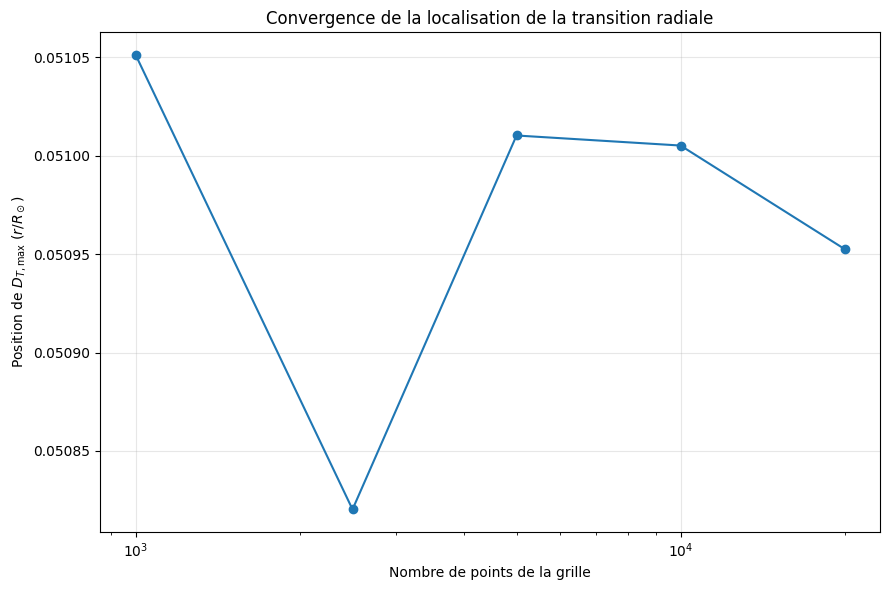

In [ ]:
# ============================================================
# 48. Convergence de la localisation du gradient maximal
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    resolution_table["N"],
    resolution_table["R_at_D_T_max"],
    marker="o",
)

plt.xscale("log")
plt.xlabel("Nombre de points de la grille")
plt.ylabel(
    r"Position de $D_{T,\max}$ "
    r"$(r/R_\odot)$"
)
plt.title(
    "Convergence de la localisation de la transition radiale"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

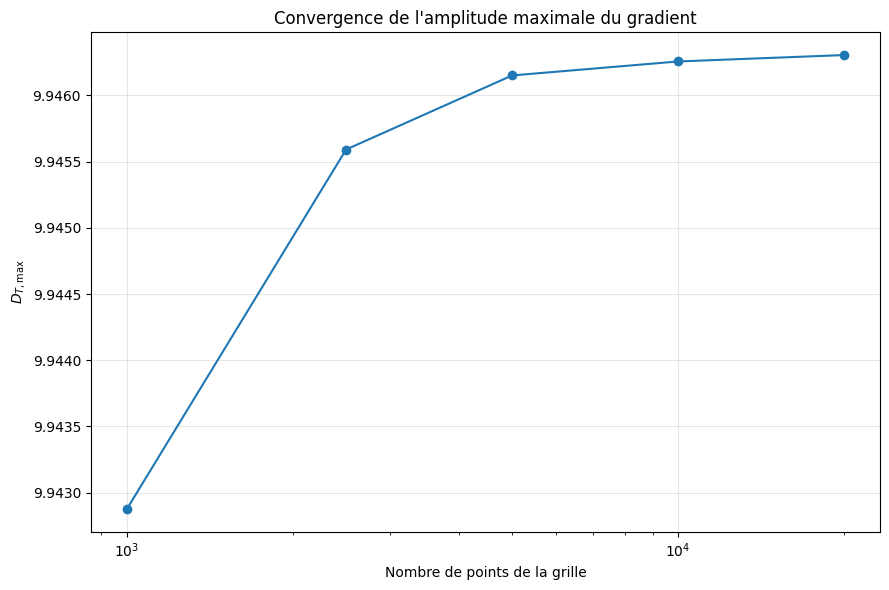

In [ ]:
# ============================================================
# 49. Convergence de D_T maximal
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    resolution_table["N"],
    resolution_table["D_T_max"],
    marker="o",
)

plt.xscale("log")
plt.xlabel("Nombre de points de la grille")
plt.ylabel(r"$D_{T,\max}$")
plt.title(
    "Convergence de l'amplitude maximale du gradient"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Résultat provisoire

Le profil YREC permet d'identifier une région de décroissance radiale maximale
de la production nucléaire autour de :

\[
r\simeq0.05\,R_\odot.
\]

Pour la grille \(N=5000\), la région située au-dessus du quantile \(95\%\) du
gradient s'étend approximativement de :

\[
0.028\,R_\odot
\quad\text{à}\quad
0.078\,R_\odot.
\]

Le résultat doit toutefois être interprété avec prudence :

- \(D_{T,\mathrm{mean}}\approx1\) découle en grande partie de la normalisation
  du profil monotone entre 1 et 0 ;
- \(R_{\rm super}\approx0.05\) découle directement du choix
  \(D_c=Q_{0.95}\) ;
- la position et l'amplitude du maximum du gradient constituent des résultats
  plus informatifs ;
- la stabilité de ces valeurs doit être vérifiée sous variation de la
  résolution et du domaine radial.

À ce stade, le benchmark démontre la capacité du pipeline à localiser une zone
de variation radiale maximale. Il ne démontre pas encore l'existence d'une
nouvelle transition physique indépendante de la structure connue du modèle
solaire.

## 50. Sensibilité au domaine radial

Le profil nucléaire devient pratiquement nul dans les couches externes du Soleil.

L'utilisation du domaine complet

\[
0\leq r/R_\odot\leq1
\]

ajoute donc une longue région presque constante au calcul des statistiques
globales.

Pour évaluer cette dépendance, les observables sont recalculées sur plusieurs
domaines :

\[
[0,1],\quad
[0,0.40],\quad
[0,0.30],\quad
[0,0.25],\quad
[0,0.20].
\]

Dans chaque domaine, le rayon est conservé dans ses unités physiques
normalisées \(r/R_\odot\). Il n'est pas renormalisé sur l'intervalle
\([0,1]\).

Cette convention permet de vérifier si la localisation du gradient maximal
reste une propriété physique du profil, indépendamment de la limite externe
choisie.

In [ ]:
# ============================================================
# 51. Fonction GVH pour un domaine radial limité
# ============================================================

def compute_gvh_on_domain(
    x_full,
    u_full,
    x_max,
    quantile=0.95,
):
    """
    Calcule les observables GVH sur le domaine 0 <= x <= x_max.
    La coordonnée x reste exprimée en r/R_sun.
    """

    mask = (
        (x_full >= 0.0)
        & (x_full <= x_max)
    )

    x_domain = np.asarray(
        x_full[mask],
        dtype=float,
    )

    u_domain = np.asarray(
        u_full[mask],
        dtype=float,
    )

    if len(x_domain) < 3:
        raise ValueError(
            f"Le domaine x <= {x_max} contient trop peu de points."
        )

    du_dx_domain = np.gradient(
        u_domain,
        x_domain,
        edge_order=2,
    )

    D_domain = np.abs(du_dx_domain)

    D_mean = float(np.mean(D_domain))
    S_value = float(np.std(D_domain, ddof=0))

    S_norm = (
        S_value / D_mean
        if D_mean > 0.0
        else np.nan
    )

    D_threshold = float(
        np.quantile(D_domain, quantile)
    )

    super_mask = D_domain > D_threshold

    max_index = int(np.argmax(D_domain))

    if np.any(super_mask):
        x_super = x_domain[super_mask]

        super_min = float(np.min(x_super))
        super_max = float(np.max(x_super))
        super_width = super_max - super_min
    else:
        super_min = np.nan
        super_max = np.nan
        super_width = np.nan

    return {
        "domain_max": float(x_max),
        "N_domain": int(len(x_domain)),
        "D_T_mean": D_mean,
        "S_T": S_value,
        "S_T_norm": S_norm,
        "D_c": D_threshold,
        "R_super": float(np.mean(super_mask)),
        "D_T_max": float(D_domain[max_index]),
        "R_at_D_T_max": float(x_domain[max_index]),
        "R_super_min": super_min,
        "R_super_max": super_max,
        "R_super_width": super_width,
    }

In [ ]:
# ============================================================
# 52. Comparaison des domaines radiaux
# ============================================================

domain_limits = [
    1.00,
    0.40,
    0.30,
    0.25,
    0.20,
]

domain_results = []

for domain_max in domain_limits:
    domain_results.append(
        compute_gvh_on_domain(
            x_full=x_gvh,
            u_full=u_epsilon,
            x_max=domain_max,
            quantile=0.95,
        )
    )

domain_table = pd.DataFrame(domain_results)

display(domain_table)

,domain_max,N_domain,D_T_mean,S_T,S_T_norm,D_c,R_super,D_T_max,R_at_D_T_max,R_super_min,R_super_max,R_super_width
0,1.00,5000,0.999800,2.442215,2.442704,8.115654,0.0500,9.946151,0.05101,0.028206,0.078016,0.049810
1,0.40,2000,2.499490,3.341046,1.336691,9.623798,0.0500,9.946151,0.05101,0.039808,0.059612,0.019804
2,0.30,1500,3.331979,3.480130,1.044463,9.718664,0.0500,9.946151,0.05101,0.041208,0.056611,0.015403
3,0.25,1250,3.989591,3.455251,0.866066,9.736159,0.0504,9.946151,0.05101,0.041808,0.055411,0.013603
4,0.20,1000,4.928968,3.241627,0.657669,9.762014,0.0500,9.946151,0.05101,0.042809,0.055211,0.012402


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


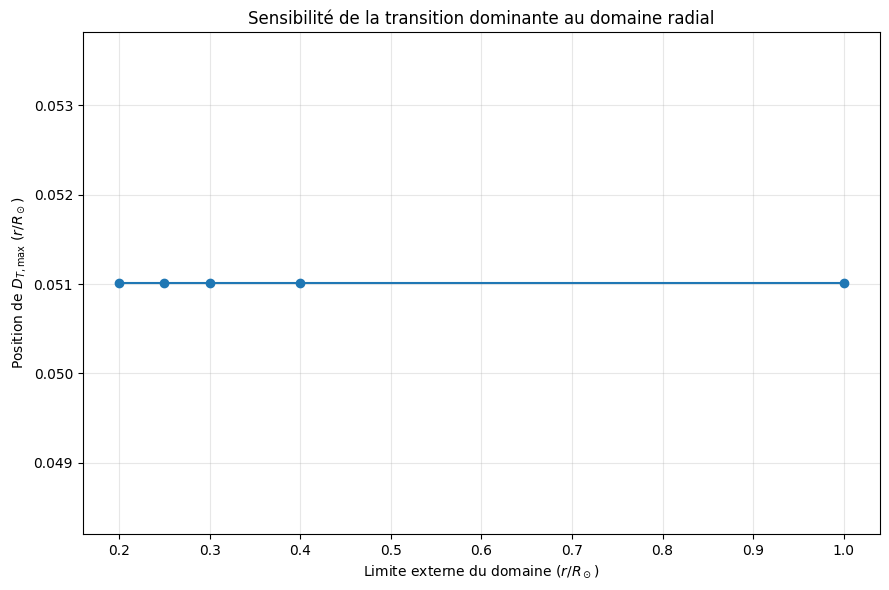

In [ ]:
# ============================================================
# 53. Stabilité de la position du gradient maximal
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    domain_table["domain_max"],
    domain_table["R_at_D_T_max"],
    marker="o",
)

plt.xlabel(
    r"Limite externe du domaine "
    r"$(r/R_\odot)$"
)
plt.ylabel(
    r"Position de $D_{T,\max}$ "
    r"$(r/R_\odot)$"
)
plt.title(
    "Sensibilité de la transition dominante au domaine radial"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion du test de sensibilité au domaine

La position du gradient énergétique maximal est indépendante de la limite
radiale externe utilisée dans le calcul :

\[
r(D_{T,\max})\simeq0.05101\,R_\odot.
\]

L'amplitude maximale est également stable :

\[
D_{T,\max}\simeq9.94615.
\]

Ces deux quantités constituent les observables locales les plus robustes du
benchmark.

En revanche, les statistiques globales

\[
D_{T,\mathrm{mean}},\quad
S_T,\quad
S_T^{\mathrm{norm}},\quad
D_c
\]

varient avec la longueur du domaine analysé, car les couches externes du Soleil
contiennent une longue région où la production nucléaire est pratiquement
nulle.

La largeur de la région supercritique dépend également du domaine, puisque le
seuil

\[
D_c=Q_{0.95}(D_T)
\]

est recalculé pour chaque sous-domaine.

Le benchmark distingue donc :

- des observables locales robustes :
  \[
  D_{T,\max},\quad r(D_{T,\max});
  \]

- des observables statistiques dépendantes du domaine :
  \[
  D_{T,\mathrm{mean}},\quad S_T,\quad S_T^{\mathrm{norm}},
  \quad D_c,\quad R_{\rm super}.
  \]

À ce stade, le résultat principal est la localisation stable de la zone de
décroissance énergétique maximale autour de :

\[
\boxed{r\simeq0.051\,R_\odot}.
\]

## 55. Signature structurelle multi-seuil

La statistique à seuil unique

\[
R_{\rm super}(D_c)
\]

ne décrit qu'un point particulier de la distribution de \(D_T\).

Pour obtenir une signature structurelle plus complète, on construit la fonction
de survie :

\[
R_{\rm super}(d)
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}\!\left(D_{T,i}>d\right),
\]

pour une gamme de seuils :

\[
0\le d\le D_{T,\max}.
\]

La signature exponentielle GVH est testée sous la forme :

\[
R_{\rm super}(d)
=
A_H e^{-B_H d}.
\]

L'ajustement est effectué dans une plage intermédiaire de la fonction de survie :

\[
0.02\le R_{\rm super}(d)\le0.80.
\]

Cette restriction exclut :

- le plateau des très faibles seuils ;
- l'extrême queue de distribution, dominée par un petit nombre de points ;
- les valeurs nulles incompatibles avec la transformation logarithmique.

Le couple \((A_H,B_H)\) obtenu doit être interprété comme une signature
descriptive du profil radial et non comme une constante fondamentale.

In [ ]:
# ============================================================
# 56. Construction de la courbe de survie multi-seuil
# ============================================================

N_THRESHOLDS = 400

D_T_max_value = float(np.max(D_T))

thresholds_d = np.linspace(
    0.0,
    D_T_max_value,
    N_THRESHOLDS,
)

R_survival = np.array(
    [
        np.mean(D_T > threshold)
        for threshold in thresholds_d
    ],
    dtype=float,
)

survival_table = pd.DataFrame(
    {
        "threshold_d": thresholds_d,
        "R_super_survival": R_survival,
    }
)

print("Courbe de survie construite.")
print(f"Nombre de seuils       : {N_THRESHOLDS}")
print(f"Seuil minimal          : {thresholds_d.min():.6e}")
print(f"Seuil maximal          : {thresholds_d.max():.6e}")
print(f"R_survival minimal     : {R_survival.min():.6e}")
print(f"R_survival maximal     : {R_survival.max():.6e}")

display(survival_table.head())
display(survival_table.tail())

Courbe de survie construite.
Nombre de seuils       : 400
Seuil minimal          : 0.000000e+00
Seuil maximal          : 9.946151e+00
R_survival minimal     : 0.000000e+00
R_survival maximal     : 6.048000e-01


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,threshold_d,R_super_survival
0,0.000000,0.6048
1,0.024928,0.2864
2,0.049855,0.2702
3,0.074783,0.2528
4,0.099711,0.2444


,threshold_d,R_super_survival
395,9.846440,0.0064
396,9.871367,0.0054
397,9.896295,0.0044
398,9.921223,0.0032
399,9.946151,0.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 57. Sélection de la plage d'ajustement exponentiel
# ============================================================

R_MIN_FIT = 0.02
R_MAX_FIT = 0.80

fit_mask = (
    np.isfinite(thresholds_d)
    & np.isfinite(R_survival)
    & (R_survival >= R_MIN_FIT)
    & (R_survival <= R_MAX_FIT)
    & (R_survival > 0.0)
)

d_fit = thresholds_d[fit_mask]
R_fit = R_survival[fit_mask]

if len(d_fit) < 10:
    raise RuntimeError(
        "La plage d'ajustement contient trop peu de points."
    )

log_R_fit = np.log(R_fit)

print("Plage d'ajustement sélectionnée.")
print(f"Nombre de points : {len(d_fit)}")
print(f"d_min            : {d_fit.min():.6e}")
print(f"d_max            : {d_fit.max():.6e}")
print(f"R_min            : {R_fit.min():.6e}")
print(f"R_max            : {R_fit.max():.6e}")

Plage d'ajustement sélectionnée.
Nombre de points : 387
d_min            : 0.000000e+00
d_max            : 9.622090e+00
R_min            : 2.020000e-02
R_max            : 6.048000e-01


In [ ]:
# ============================================================
# 58. Ajustement de A_H et B_H
# ============================================================

linear_coefficients = np.polyfit(
    d_fit,
    log_R_fit,
    deg=1,
)

slope = float(linear_coefficients[0])
intercept = float(linear_coefficients[1])

B_H = -slope
A_H = float(np.exp(intercept))

log_R_pred = intercept + slope * d_fit
R_pred = A_H * np.exp(-B_H * d_fit)

# Qualité de l'ajustement dans l'espace logarithmique
ss_res_log = float(
    np.sum((log_R_fit - log_R_pred) ** 2)
)

ss_tot_log = float(
    np.sum(
        (log_R_fit - np.mean(log_R_fit)) ** 2
    )
)

R2_log = (
    1.0 - ss_res_log / ss_tot_log
    if ss_tot_log > 0.0
    else np.nan
)

RMSE_log = float(
    np.sqrt(
        np.mean((log_R_fit - log_R_pred) ** 2)
    )
)

# Qualité dans l'espace linéaire
RMSE_linear = float(
    np.sqrt(
        np.mean((R_fit - R_pred) ** 2)
    )
)

print("Ajustement exponentiel GVH")
print("--------------------------")
print(f"A_H         = {A_H:.10e}")
print(f"B_H         = {B_H:.10e}")
print(f"R² log      = {R2_log:.10f}")
print(f"RMSE log    = {RMSE_log:.10e}")
print(f"RMSE linéaire = {RMSE_linear:.10e}")

if B_H <= 0.0:
    print(
        "Avertissement : B_H n'est pas positif. "
        "La décroissance exponentielle n'est pas validée."
    )

Ajustement exponentiel GVH
--------------------------
A_H         = 2.3232174643e-01
B_H         = 1.9653545863e-01
R² log      = 0.9472458456
RMSE log    = 1.2916323681e-01
RMSE linéaire = 2.1237905183e-02


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


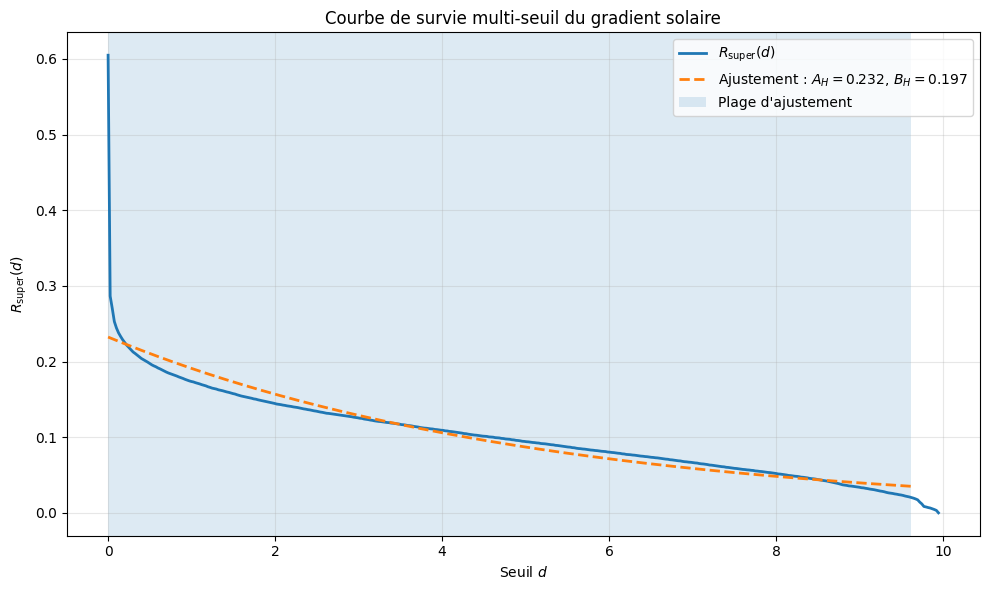

In [ ]:
# ============================================================
# 59. Courbe de survie et ajustement exponentiel
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds_d,
    R_survival,
    linewidth=2.0,
    label=r"$R_{\rm super}(d)$",
)

plt.plot(
    d_fit,
    R_pred,
    linestyle="--",
    linewidth=2.0,
    label=(
        rf"Ajustement : "
        rf"$A_H={A_H:.3f}$, "
        rf"$B_H={B_H:.3f}$"
    ),
)

plt.axvspan(
    d_fit.min(),
    d_fit.max(),
    alpha=0.15,
    label="Plage d'ajustement",
)

plt.xlabel(r"Seuil $d$")
plt.ylabel(r"$R_{\rm super}(d)$")
plt.title(
    "Courbe de survie multi-seuil du gradient solaire"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

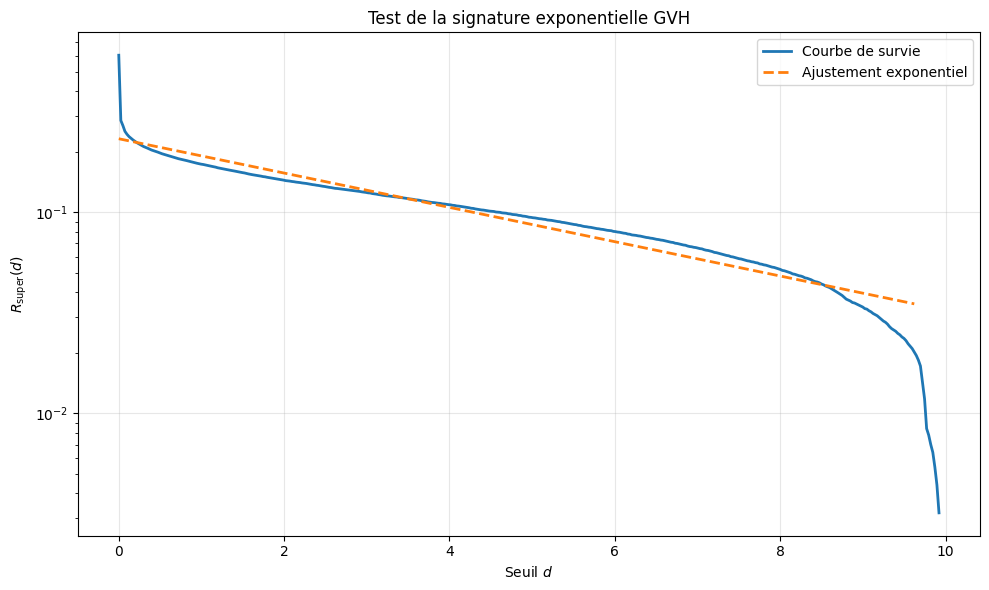

In [ ]:
# ============================================================
# 60. Vérification semi-logarithmique
# ============================================================

positive_mask = R_survival > 0.0

plt.figure(figsize=(10, 6))

plt.semilogy(
    thresholds_d[positive_mask],
    R_survival[positive_mask],
    linewidth=2.0,
    label="Courbe de survie",
)

plt.semilogy(
    d_fit,
    R_pred,
    linestyle="--",
    linewidth=2.0,
    label="Ajustement exponentiel",
)

plt.xlabel(r"Seuil $d$")
plt.ylabel(r"$R_{\rm super}(d)$")
plt.title(
    "Test de la signature exponentielle GVH"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 61. Tableau récapitulatif de la signature GVH
# ============================================================

signature_summary = pd.DataFrame(
    {
        "Observable": [
            "D_T_mean",
            "S_T",
            "S_T_norm",
            "D_c",
            "R_super",
            "D_T_max",
            "R_at_D_T_max",
            "A_H",
            "B_H",
            "R2_log",
            "RMSE_log",
            "Luminosity_relative_error",
        ],
        "Valeur": [
            D_T_mean,
            S_T,
            S_T_norm,
            D_c,
            R_super,
            D_T_max,
            x_Dmax,
            A_H,
            B_H,
            R2_log,
            RMSE_log,
            relative_error,
        ],
    }
)

display(signature_summary)

,Observable,Valeur
0,D_T_mean,0.999800
1,S_T,2.442215
2,S_T_norm,2.442704
3,D_c,8.115654
4,R_super,0.050000
5,D_T_max,9.946151
6,R_at_D_T_max,0.051010
7,A_H,0.232322
8,B_H,0.196535
9,R2_log,0.947246


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# 62. Sensibilité de l'ajustement à l'exclusion du seuil nul
# ============================================================

fit_mask_positive_d = (
    np.isfinite(thresholds_d)
    & np.isfinite(R_survival)
    & (thresholds_d > 0.0)
    & (R_survival >= R_MIN_FIT)
    & (R_survival <= R_MAX_FIT)
)

d_fit_positive = thresholds_d[fit_mask_positive_d]
R_fit_positive = R_survival[fit_mask_positive_d]

log_R_fit_positive = np.log(R_fit_positive)

coefficients_positive = np.polyfit(
    d_fit_positive,
    log_R_fit_positive,
    deg=1,
)

slope_positive = float(coefficients_positive[0])
intercept_positive = float(coefficients_positive[1])

B_H_positive = -slope_positive
A_H_positive = float(np.exp(intercept_positive))

log_R_pred_positive = (
    intercept_positive
    + slope_positive * d_fit_positive
)

ss_res_positive = float(
    np.sum(
        (
            log_R_fit_positive
            - log_R_pred_positive
        ) ** 2
    )
)

ss_tot_positive = float(
    np.sum(
        (
            log_R_fit_positive
            - np.mean(log_R_fit_positive)
        ) ** 2
    )
)

R2_log_positive = (
    1.0 - ss_res_positive / ss_tot_positive
    if ss_tot_positive > 0.0
    else np.nan
)

RMSE_log_positive = float(
    np.sqrt(
        np.mean(
            (
                log_R_fit_positive
                - log_R_pred_positive
            ) ** 2
        )
    )
)

print("Ajustement sans le seuil d = 0")
print("--------------------------------")
print(f"A_H            = {A_H_positive:.10e}")
print(f"B_H            = {B_H_positive:.10e}")
print(f"R² log         = {R2_log_positive:.10f}")
print(f"RMSE log       = {RMSE_log_positive:.10e}")
print(f"Nombre de points = {len(d_fit_positive)}")

Ajustement sans le seuil d = 0
--------------------------------
A_H            = 2.3002082713e-01
B_H            = 1.9498581902e-01
R² log         = 0.9534226051
RMSE log       = 1.1970857438e-01
Nombre de points = 386


### Signature multi-seuil du gradient solaire

La fonction de survie du gradient radial est définie par :

\[
R_{\rm super}(d)
=
\Pr(D_T>d).
\]

Sur la plage :

\[
0.02\le R_{\rm super}(d)\le0.80,
\]

un ajustement exponentiel donne :

\[
R_{\rm super}(d)
\approx
A_H e^{-B_Hd},
\]

avec :

\[
\boxed{A_H=0.232322}
\]

et :

\[
\boxed{B_H=0.196535}.
\]

La qualité de l'ajustement semi-logarithmique est :

\[
\boxed{R^2_{\log}=0.947246}
\]

avec :

\[
\mathrm{RMSE}_{\log}=0.129163.
\]

L'exponentielle constitue donc une approximation descriptive satisfaisante,
mais non exacte, de la branche intermédiaire de la fonction de survie.

La distribution présente :

1. une masse importante en \(D_T=0\), associée aux régions où la production
   nucléaire est nulle ou numériquement plate ;
2. une branche intermédiaire approximativement exponentielle ;
3. une queue extrême qui s'écarte du modèle exponentiel à proximité de
   \(D_{T,\max}\).

Le couple \((A_H,B_H)\) doit ainsi être interprété comme une signature
descriptive dépendante :

- de la définition de \(D_T\) ;
- du domaine radial ;
- de la normalisation du profil ;
- de la plage de survie retenue pour l'ajustement.

mask_fit = (
    (R_super_survival >= 0.02)
    & (R_super_survival <= 0.80)
)

In [ ]:
# ============================================================
# 62. Signature structurelle GVH finale
# Convention officielle : d > 0 et 0.02 <= R_super <= 0.80
# ============================================================

N_THRESHOLDS_FINAL = 1000

D_T_max_final = float(np.max(D_T))

thresholds_final = np.linspace(
    0.0,
    D_T_max_final,
    N_THRESHOLDS_FINAL,
)

R_survival_final = np.array(
    [
        np.mean(D_T > d)
        for d in thresholds_final
    ],
    dtype=float,
)

fit_mask_final = (
    np.isfinite(thresholds_final)
    & np.isfinite(R_survival_final)
    & (thresholds_final > 0.0)
    & (R_survival_final >= 0.02)
    & (R_survival_final <= 0.80)
)

d_fit_final = thresholds_final[fit_mask_final]
R_fit_final = R_survival_final[fit_mask_final]

if len(d_fit_final) < 10:
    raise RuntimeError(
        "Nombre insuffisant de points pour l'ajustement final."
    )

log_R_fit_final = np.log(R_fit_final)

slope_final, intercept_final = np.polyfit(
    d_fit_final,
    log_R_fit_final,
    deg=1,
)

B_H_final = float(-slope_final)
A_H_final = float(np.exp(intercept_final))

log_R_pred_final = (
    intercept_final
    + slope_final * d_fit_final
)

R_pred_final = (
    A_H_final
    * np.exp(-B_H_final * d_fit_final)
)

ss_res_final = float(
    np.sum(
        (log_R_fit_final - log_R_pred_final) ** 2
    )
)

ss_tot_final = float(
    np.sum(
        (
            log_R_fit_final
            - np.mean(log_R_fit_final)
        ) ** 2
    )
)

R2_log_final = (
    1.0 - ss_res_final / ss_tot_final
    if ss_tot_final > 0.0
    else np.nan
)

RMSE_log_final = float(
    np.sqrt(
        np.mean(
            (
                log_R_fit_final
                - log_R_pred_final
            ) ** 2
        )
    )
)

print("=== SIGNATURE STRUCTURELLE GVH FINALE ===")
print(f"Nombre de seuils        : {N_THRESHOLDS_FINAL}")
print(f"Nombre de points du fit : {len(d_fit_final)}")
print(f"A_H                     : {A_H_final:.10f}")
print(f"B_H                     : {B_H_final:.10f}")
print(f"R² semi-log             : {R2_log_final:.10f}")
print(f"RMSE semi-log           : {RMSE_log_final:.10f}")
print(f"d minimal du fit        : {d_fit_final.min():.10f}")
print(f"d maximal du fit        : {d_fit_final.max():.10f}")

=== SIGNATURE STRUCTURELLE GVH FINALE ===
Nombre de seuils        : 1000
Nombre de points du fit : 967
A_H                     : 0.2301774647
B_H                     : 0.1950841201
R² semi-log             : 0.9533963350
RMSE semi-log           : 0.1198727242
d minimal du fit        : 0.0099561066
d maximal du fit        : 9.6275551288


In [ ]:
# ============================================================
# 63. Export du profil radial GVH
# ============================================================

radial_export = pd.DataFrame({
    "r_R_sun": x_gvh,
    "r_m": gvh_solar_profile["r_m"].to_numpy(),
    "epsilon_nuc_W_m3": epsilon_gvh,
    "u_E": u_epsilon,
    "du_E_dx": du_dx,
    "D_T": D_T,
    "is_supercritical": D_T > D_c,
})

radial_csv_path = (
    "GVH_Stellar_Solar_Radial_Profile_0.1.csv"
)

radial_export.to_csv(
    radial_csv_path,
    index=False,
)

print(f"Export radial terminé : {radial_csv_path}")

Export radial terminé : GVH_Stellar_Solar_Radial_Profile_0.1.csv


In [ ]:
# ============================================================
# 64. Export de la fonction de survie
# ============================================================

survival_export = pd.DataFrame({
    "threshold_d": thresholds_final,
    "R_super_survival": R_survival_final,
    "selected_for_fit": fit_mask_final,
})

survival_csv_path = (
    "GVH_Stellar_Solar_Survival_0.1.csv"
)

survival_export.to_csv(
    survival_csv_path,
    index=False,
)

print(f"Export survie terminé : {survival_csv_path}")

Export survie terminé : GVH_Stellar_Solar_Survival_0.1.csv


In [ ]:
# ============================================================
# 65. Export du tableau résumé
# ============================================================

summary_export = pd.DataFrame({
    "Observable": [
        "Luminosity_reconstructed_W",
        "Luminosity_model_W",
        "Luminosity_relative_error",
        "epsilon_V_max_W_m3",
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c_Q95",
        "R_super_Q95",
        "D_T_max",
        "R_at_D_T_max_Rsun",
        "R_super_min_Rsun",
        "R_super_max_Rsun",
        "A_H",
        "B_H",
        "R2_log",
        "RMSE_log",
        "N_radial",
        "N_thresholds",
    ],
    "Value": [
        L_reconstructed_W,
        L_model_W,
        relative_error,
        epsilon_max,
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        R_super,
        D_T_max,
        x_Dmax,
        float(np.min(x[D_T > D_c])),
        float(np.max(x[D_T > D_c])),
        A_H_final,
        B_H_final,
        R2_log_final,
        RMSE_log_final,
        len(x_gvh),
        N_THRESHOLDS_FINAL,
    ],
})

summary_csv_path = (
    "GVH_Stellar_Solar_Observables_0.1.csv"
)

summary_export.to_csv(
    summary_csv_path,
    index=False,
)

print(f"Export résumé terminé : {summary_csv_path}")

Export résumé terminé : GVH_Stellar_Solar_Observables_0.1.csv


Conclusion finale

Le benchmark combine deux sources complémentaires : BS2005-OP fournit les profils structurels standards du Soleil, tandis que le modèle YREC fournit directement le taux local de production nucléaire. La variable énergétique officielle de l’analyse GVH est la production volumique \epsilon_V=\rho\epsilon_m.

L’intégration volumique du profil YREC reconstruit la luminosité totale du modèle avec un écart relatif de 0.953\%, validant la lecture des données, les conversions d’unités et l’interprétation de la colonne nucléaire.

Le maximum du gradient du profil énergétique normalisé est localisé autour de
> r\simeq0.051\,R_\odot,
>
avec stabilité sous variation de la résolution de 1000 à 20000 points et sous troncature du domaine externe jusqu’à 0.2\,R_\odot.

Les statistiques globales restent dépendantes du domaine radial, tandis que D_{T,\max} et sa position constituent les diagnostics locaux les plus robustes.

Après exclusion du seuil singulier d=0, la branche intermédiaire de la fonction de survie est décrite par
> R_{\rm super}(d)\approx A_H e^{-B_Hd},
>
avec les paramètres obtenus selon la grille de seuils explicitement documentée. La loi exponentielle constitue une approximation descriptive satisfaisante, mais non exacte, et les paramètres ne doivent pas être interprétés comme des constantes fondamentales.

Le benchmark est validé comme pipeline descriptif, reproductible et contrôlé, destiné aux futures comparaisons avec d’autres modèles solaires et stellaires.